## Expected Credit Loss (ECL) Modeling for Retail Loans
## Notebook 2
## EDA, Feature Engineering

---


## Author: Will Wu

## Date: 2025-11-14
---

## **Table of Contents** ##

1. [Setup and Loading](#1)
2. [Train Test Split](#2)
3. [EDA](#3)
    - [Probability of Default (PD)](#3a)
    - [Loss Given Default (LGD)](#3b)
    - [Exposure at Default (EAD)](#3c)
    - [Univariate Analysis](#3d)
    - [Outliers Analysis](#3e)
    - [Multivariate Analysis](#3f)
        - [Correlation Heatmap](#3f1)
        - [Borrower Attributes](#3f2)
        - [Loan Characteristics](#3f3)
        - [Performance Variables](#3f4)
        - [Derived Features](#3f5)

4. [Summary](#4)


---

## 1. Setup and Loading<a class="anchor" id="1"></a>

In [1]:
import pandas as pd
import numpy as np 
import math
import matplotlib as mpl
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Set Pandas option to display floats with 4 decimal places, preventing scientific notation
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set the style
sns.set(style="whitegrid")

# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the dataset
loan_df = pd.read_csv("../data/loan_clean.csv", index_col=0)

In [4]:
# Check the head
loan_df.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
1,7500,7500,36,13.7500,255.4300,E,E2,0,OWN,22000.0000,Not Verified,2007-06-01,Fully Paid,debt_consolidation,MA,14.2900,1.0000,0.0000,11.0000,7.0000,0.0000,4175,51.5000,8.0000,f,0.0000,9194.9800,7500.0000,1694.9800,0.0000,0.0000,0.0000,256.5900,0.0000,0.0000,0,0.0000,0.0000
2,6000,6000,36,10.5900,195.2800,C,C2,0,RENT,20000.0000,Not Verified,2007-06-01,Does not meet the credit policy. Status:Fully ...,debt_consolidation,CT,12.9000,0.0000,4.0000,45.0000,5.0000,0.0000,13660,66.0000,6.0000,f,0.0000,7029.5300,6000.0000,1029.5300,0.0000,0.0000,0.0000,197.3600,0.0000,0.0000,0,0.0000,0.0000
3,4400,4400,36,9.6400,141.2500,B,B4,2,MORTGAGE,30000.0000,Not Verified,2007-06-01,Does not meet the credit policy. Status:Fully ...,debt_consolidation,NJ,3.7200,0.0000,0.0000,0.0000,4.0000,0.0000,3493,63.5000,5.0000,f,0.0000,5084.4700,4400.0000,684.4700,0.0000,0.0000,0.0000,143.2800,0.0000,0.0000,0,0.0000,0.0000
24,5000,5000,36,11.2200,164.2300,C,C4,1,OWN,30000.0000,Not Verified,2007-07-01,Fully Paid,credit_card,GA,18.6400,0.0000,0.0000,0.0000,10.0000,0.0000,15840,47.1000,12.0000,f,0.0000,5911.7600,5000.0000,911.7600,0.0000,0.0000,0.0000,166.2500,0.0000,0.0000,0,0.0000,0.0000
25,3000,3000,36,8.7000,94.9800,B,B1,0,MORTGAGE,25000.0000,Not Verified,2007-07-01,Fully Paid,small_business,MA,14.5400,0.0000,1.0000,0.0000,10.0000,0.0000,3660,7.8000,13.0000,f,0.0000,3418.8800,3000.0000,418.8800,0.0000,0.0000,0.0000,97.4500,0.0000,0.0000,0,0.0000,0.0000


In [5]:
# Check the shape
loan_df.shape

(444949, 38)

In [6]:
# Check the info
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 444949 entries, 1 to 466284
Data columns (total 38 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   loan_amnt                int64  
 1   funded_amnt              int64  
 2   term                     int64  
 3   int_rate                 float64
 4   installment              float64
 5   grade                    object 
 6   sub_grade                object 
 7   emp_length               int64  
 8   home_ownership           object 
 9   annual_inc               float64
 10  verification_status      object 
 11  issue_d                  object 
 12  loan_status              object 
 13  purpose                  object 
 14  addr_state               object 
 15  dti                      float64
 16  delinq_2yrs              float64
 17  inq_last_6mths           float64
 18  mths_since_last_delinq   float64
 19  open_acc                 float64
 20  pub_rec                  float64
 21  revol_bal      

In [7]:
# Transform issue_d to datetime format
loan_df['issue_d'] = pd.to_datetime(loan_df['issue_d'])

---

## 2. Train Test Split <a class="anchor" id="2"></a>

As mentioned in Notebook 1, it is crucial to sort and split the train and test datasets in temporal order. Credit risks tend to evolve over time, influenced by macroeconomic factors. Although this dataset currently doesn't incorporate macroeconomic facotrs, random splitting can still introduce subtle biases that slightly alter our results. 

In [8]:
# Calculate index for 70% split
train_size = int(0.7 * len(loan_df))

# Check the cutoff time
cutoff_time = loan_df.iloc[:train_size]['issue_d'].iloc[-1]
cutoff_time

Timestamp('2014-06-01 00:00:00')

In [9]:
# Split based on the cutoff date
train_df = loan_df.loc[loan_df['issue_d'] <= cutoff_time].copy()
test_df = loan_df.loc[loan_df['issue_d'] > cutoff_time].copy()


print(f"Train data size: {train_df.shape[0]},\
    Issue_date: starts at {train_df['issue_d'].min()}, ends at {train_df['issue_d'].max()}")
print(f"Test data size: {test_df.shape[0]},\
    Issue_date: starts at {test_df['issue_d'].min()}, ends at {test_df['issue_d'].max()}")

Train data size: 318851,    Issue_date: starts at 2007-06-01 00:00:00, ends at 2014-06-01 00:00:00
Test data size: 126098,    Issue_date: starts at 2014-07-01 00:00:00, ends at 2014-12-01 00:00:00


---

## 3. EDA <a class="anchor" id="3"></a>

1. In this section, I will conduct exploratory data analysis (EDA), primarily aimed at generating insights into our target variables—Probability of Default (PD), Loss Given Default (LGD), and Exposure at Default (EAD)—which will be essential for subsequent modeling.

2. I will perform both univariate and multivariate analysis to understand the distribution of predictors and analyze how they influence our target variables.

3. Since I plan to build various Generalized Linear Models (GLMs) for modeling PD and LGD in upcoming steps, I will also examine the correlation among predictors to identify and prevent issues related to collinearity.


In [10]:
# Extract categorical columns (usually object or category dtype)
categorical_cols = loan_df.select_dtypes(include=['object', 'category']).columns

# Extract numerical columns (int, float)
numerical_cols = loan_df.select_dtypes(include=['number']).columns

# Target columns to remove
target_columns = ['is_default', 'exposure_at_default', 'loss_given_default', 'recoveries', 
                  'collection_recovery_fee','loan_status']

# Remove from numerical columns
numerical_cols = [col for col in numerical_cols if col not in target_columns]

# Remove from categorical columns
categorical_cols = [col for col in categorical_cols if col not in target_columns]

# Print the counts after removal
print(f"Remaining numerical variables: {len(numerical_cols)}")
print(f"Remaining categorical variables: {len(categorical_cols)}")


Remaining numerical variables: 24
Remaining categorical variables: 7


### 3.1 Probability of Default (PD) <a class="anchor" id="3a"></a>

#### Long-Term PD  / PD Through The Cycle 

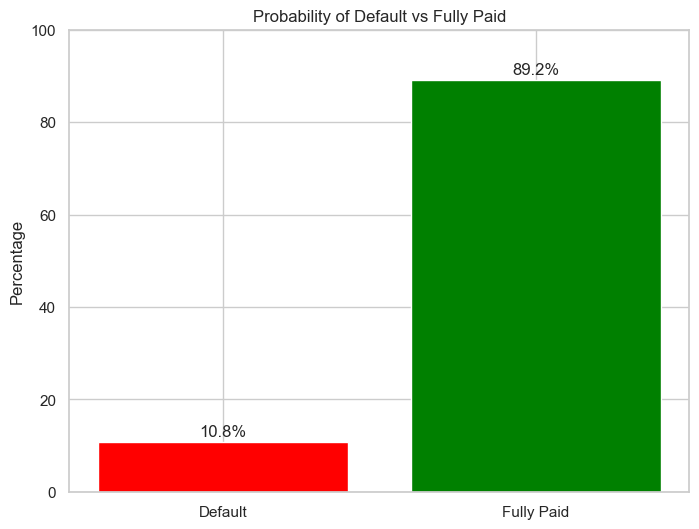

In [11]:
# Calculate probabilities
default_pct = loan_df['is_default'].mean() * 100
fully_paid_pct = 100 - default_pct


# Plot
plt.figure(figsize=(8, 6))
plt.bar(['Default', 'Fully Paid'], [default_pct, fully_paid_pct], color=['red', 'green'])
plt.ylabel('Percentage')
plt.title('Probability of Default vs Fully Paid')
for i, v in enumerate([default_pct, fully_paid_pct]):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom')

plt.ylim(0, 100)
plt.show()

### Plot Monthly PD (PD Point In Time) over time

In banks or real life: montly PD is calcualted as  $$\text{Monthly PD}  = \frac{\text{\# Loans that Defaulted THIS Month}}{\text{\# Total Loans on the book at the start of THIS Month}}$$ 

However, I will use total loans issued this month as a surrogate. So my calculation is based on:

$$\text{Monthly PD} = \frac{\text{\# Defaulted Loans Issued in that Month}}{\text{\# Total Loans Issued in that Month}}$$

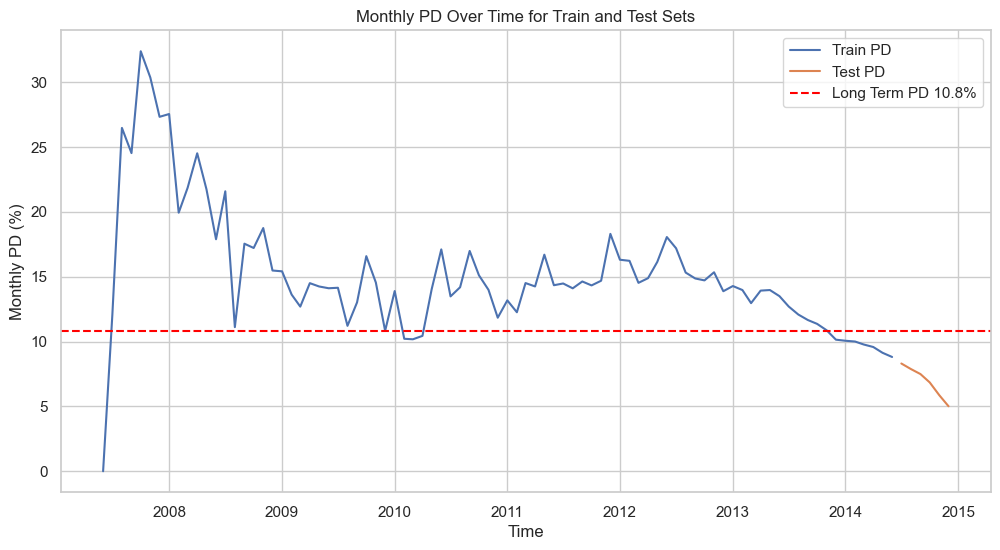

In [12]:
# Calculate monthly PDs for train and test
train_pd = (train_df.groupby(train_df['issue_d'].dt.to_period('M'))['is_default'].mean() * 100).reset_index()
test_pd = (test_df.groupby(test_df['issue_d'].dt.to_period('M'))['is_default'].mean() * 100).reset_index()

# Convert Period to timestamp for plotting
train_pd['issue_d'] = train_pd['issue_d'].dt.to_timestamp()
test_pd['issue_d'] = test_pd['issue_d'].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(train_pd['issue_d'], train_pd['is_default'], label='Train PD')
plt.plot(test_pd['issue_d'], test_pd['is_default'], label='Test PD')
plt.axhline(y=default_pct, ls='--', color='red', label=f'Long Term PD {default_pct:.1f}%')

plt.xlabel('Time')
plt.ylabel('Monthly PD (%)')
plt.title('Monthly PD Over Time for Train and Test Sets')
plt.legend()
plt.grid(True)
plt.show()

- **Insights**
1. The **long-term probability of default (PD)** across the entire study period is **10.8%**, which is relatively high. This indicates that about 1 of every 10 loans issued on Lending Club from 2007 to 2014 has defaulted, reflecting inherent risk in the portfolio, and room for risk mitigation.
2. The second plot clearly shows that **PD is not static over time**; it exhibits significant volatility. Notably, there is a spike around 2017, followed by a gradual decline, and then a relatively stable level from 2009 to the end of 2012. After that, a decreasing trend in PD is evident.
3. The variability in PD over time suggests that **we should retrain our PD models regularly** (e.g., annually), as using a **long-term PD estimate may not accurately reflect the current risk environment**.
4. It may be more effective to develop several PD models using the latest data rather than relying solely on a fixed train-test split, to ensure models stay aligned with the most recent trends.
5. If possible, I will incorporate Macroeconomic Environment Data (MEVs) to enhance the model’s ability to account for macroeconomic factors that influence credit risk.
6. The PD reveals that we are dealing with an imbalanced dataset when building the model, highlighting the need for resampling techniques before training. Additionally, our evaluation should prioritize recall and precision scores instead of relying solely on accuracy for decision-making.
---

### 3.2 Loss Given Default (LGD) <a class="anchor" id="3b"></a>

#### Long-Term LGD  / LGD Through The Cycle 

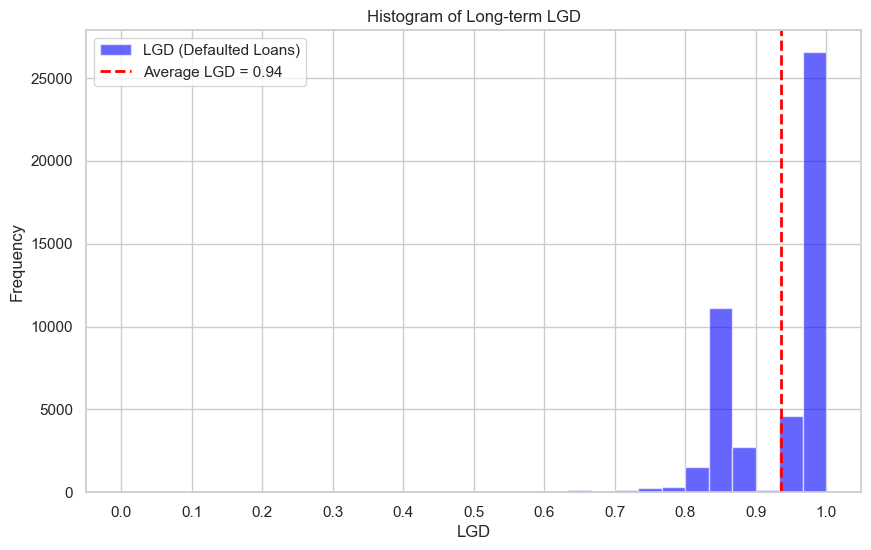

In [13]:
# Filter to include only defaulted loans
default_loans = loan_df[loan_df['is_default'] == 1]

# Plot histogram of LGD for defaulted loans
plt.figure(figsize=(10, 6))
plt.hist(default_loans['loss_given_default'], bins=30, alpha=0.6, label='LGD (Defaulted Loans)', color='blue')

# Calculate and plot the Average LGD for defaulted loans
average_lgd = default_loans['loss_given_default'].mean()
plt.axvline(average_lgd, color='red', linestyle='--', linewidth=2, label=f'Average LGD = {average_lgd:.2f}')

# Add labels and title
plt.xlabel('LGD')
plt.ylabel('Frequency')
plt.title('Histogram of Long-term LGD')
plt.xticks(np.arange(0, 1.1, 0.1))
plt.legend()
plt.show()

#### LGD Over Time — Annual LGD from 2007 to 2014

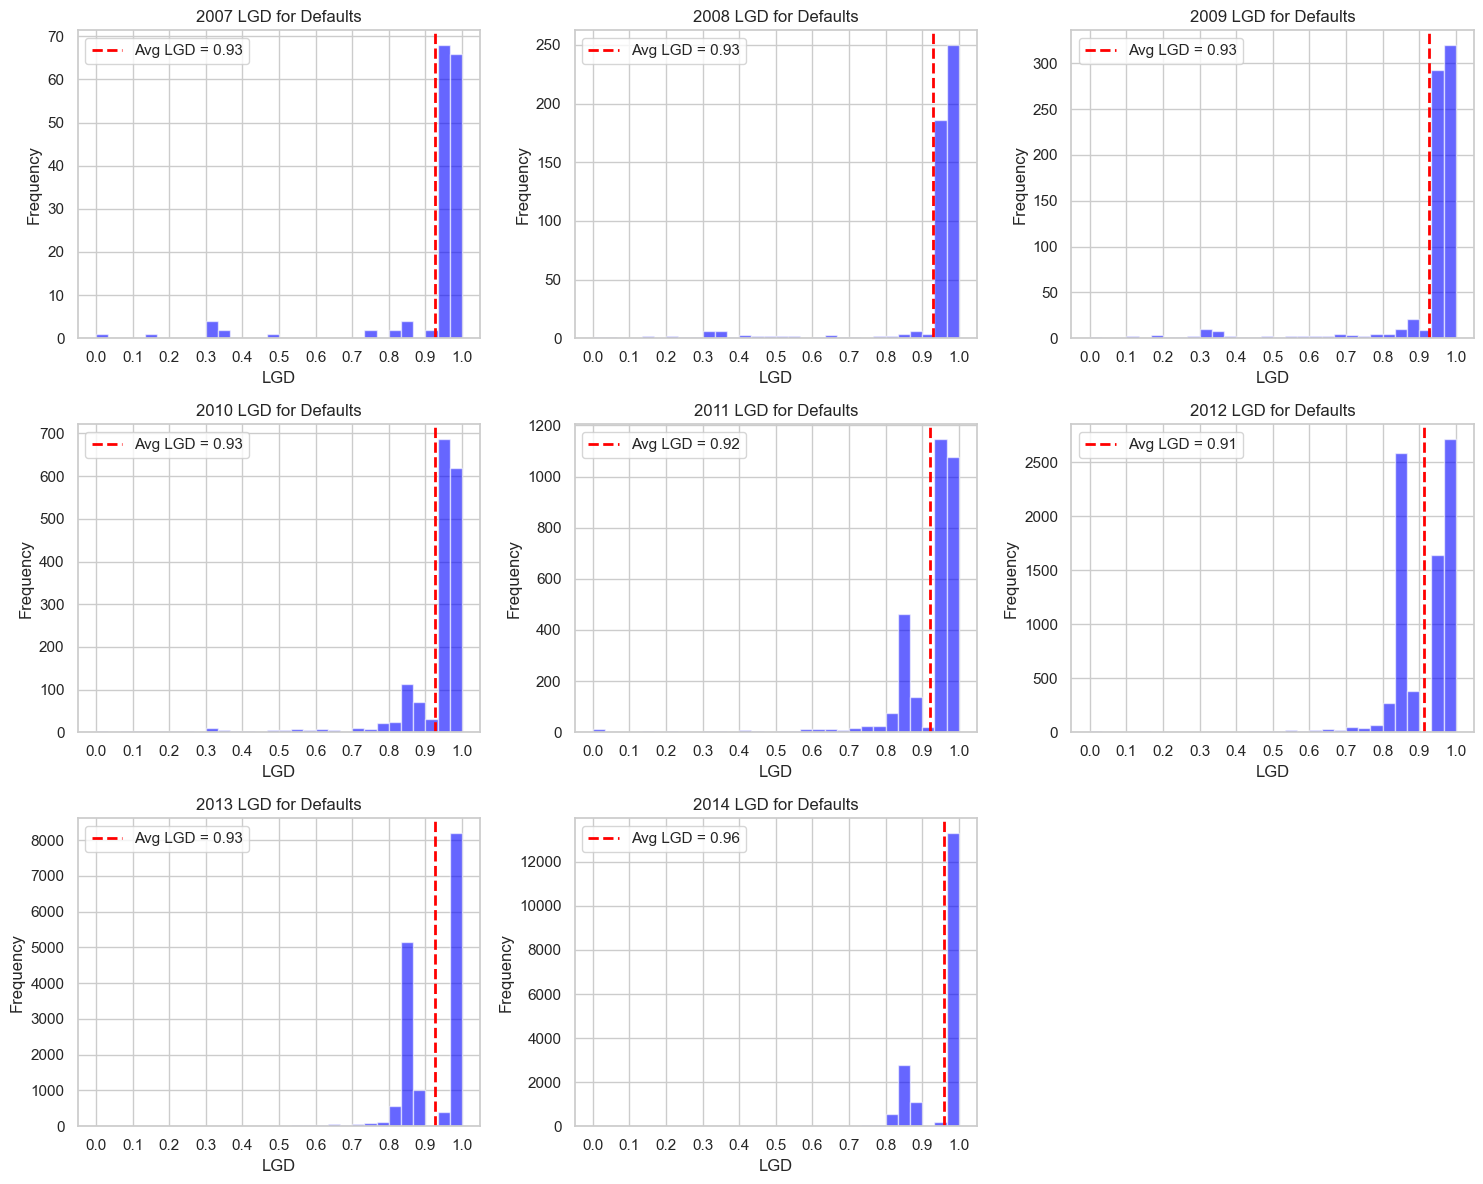

In [14]:
# Plot LGD by year
years = list(range(2007, 2015))  
n_years = len(years)

# Calculating rows needed for 3 plots per row
n_cols = 3
n_rows = math.ceil(n_years / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))

# Make axes a 2D array if only one row
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)
# If only one column, keep consistent shape
if n_cols == 1:
    axes = np.expand_dims(axes, axis=1)

# Plot for each year
for i, year in enumerate(years):
    row_idx = i // n_cols
    col_idx = i % n_cols
    ax = axes[row_idx, col_idx]

    # Filter data for the year
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    mask = (loan_df['issue_d'] >= start_date) & (loan_df['issue_d'] <= end_date)
    year_data = loan_df[mask]
    default_data = year_data[year_data['is_default'] == 1]

    # Plot histogram
    ax.hist(default_data['loss_given_default'], bins=30, alpha=0.6, color='blue')
    avg_lgd = default_data['loss_given_default'].mean()
    ax.axvline(avg_lgd, color='red', linestyle='--', linewidth=2, label=f'Avg LGD = {avg_lgd:.2f}')
    ax.set_title(f'{year} LGD for Defaults')
    ax.set_xlabel('LGD')
    ax.set_ylabel('Frequency')
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.legend()

# Remove any empty subplots (if total subplots > number of years)
for j in range(i+1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

- **Insights:**
1. The distribution of `Loss_Given_Default` is **bimodal**, with **prominent peaks at 0% and around 85%**. The peak at 0% indicates many defaulted loans where the lender recovered nothing—the entire principal was lost. The peak around 85% suggests that, for some loans, a significant portion of exposure was recovered, resulting in LGD around 15%.

2. Comparing LGD distributions across years **from 2007 to 2014**, we observe **noticeable variation**. From 2007 to 2009, the distribution is bimodal with peaks at 0 and near 1, but starting around 2010, the peaks shift to 0 and approximately 0.85. **In 2012, the peak at 0.85 is especially prominent**, indicating a higher frequency of LGD around that level.

3. The yearly shifts highlight the importance of regularly retraining LGD models, as the distribution varies significantly over time.

4. The bimodal shape suggests that LGD modeling is primarily a classification problem—distinguishing between low and high LGD—followed by regression to estimate exact values. This approach aligns with real-world banking practices.
      #### 1. Stage 1: Zero-Loss Classifier 
      - Targets loans with LGD = 0%.  
      - Model: Logistic or Probit Regression.  
      - Output: $P_{\text{LGD}=0}$ (The probability of a zero loss).

      #### 2. Stage 2: Full-Loss Classifier  
      - Focuses on cases with total loss (LGD = 100%).  
      - Model: Logistic or Probit Regression.  
      - Output: $P_{\text{LGD}=1}$ (The probability of a total loss).

      #### 3. Stage 3: Partial Loss Regression  
      - Models partial losses (e.g., LGD ≈ 0.85).  
      - Model: Beta Regression.  
      - Data: Only loans with \( 0 < LGD < 100\% \).  
      - Output: $\text{LGD}_{cont}$ (The predicted $\text{LGD}$ for partial loss cases).

      #### Final LGD Calculation:  
   $$\text{LGD}_{\text{final}} = (P_{\text{LGD}=1} \cdot 1) + (P_{\text{LGD}=0} \cdot 0) + (1 - P_{\text{LGD}=1} - P_{\text{LGD}=0}) \cdot \text{LGD}_{cont}$$
---

### 3.3 Exposure at Default (EAD) <a class="anchor" id="3c"></a>

Exposure at Default (EAD) represents the outstanding principal amount that is subject to loss at the time of default. For term loans, `loan_amnt` and `funded_amnt` are typically similar, as borrowers usually fund the entire amount upfront. In contrast, for revolving credit products like credit cards, borrowers may not utilize the full credit line, resulting in differences between these variables.

Due to the difficulty in obtaining accurate amount drawn at default data for credit card, CCF modeling is not feasible. Therefore, EAD modeling will not be the focus of this project; instead, we will simply use the outstanding principal as our EAD. Nonetheless, exploring this variable through EDA can still provide valuable insights.


#### Funded Amount vs. EAD


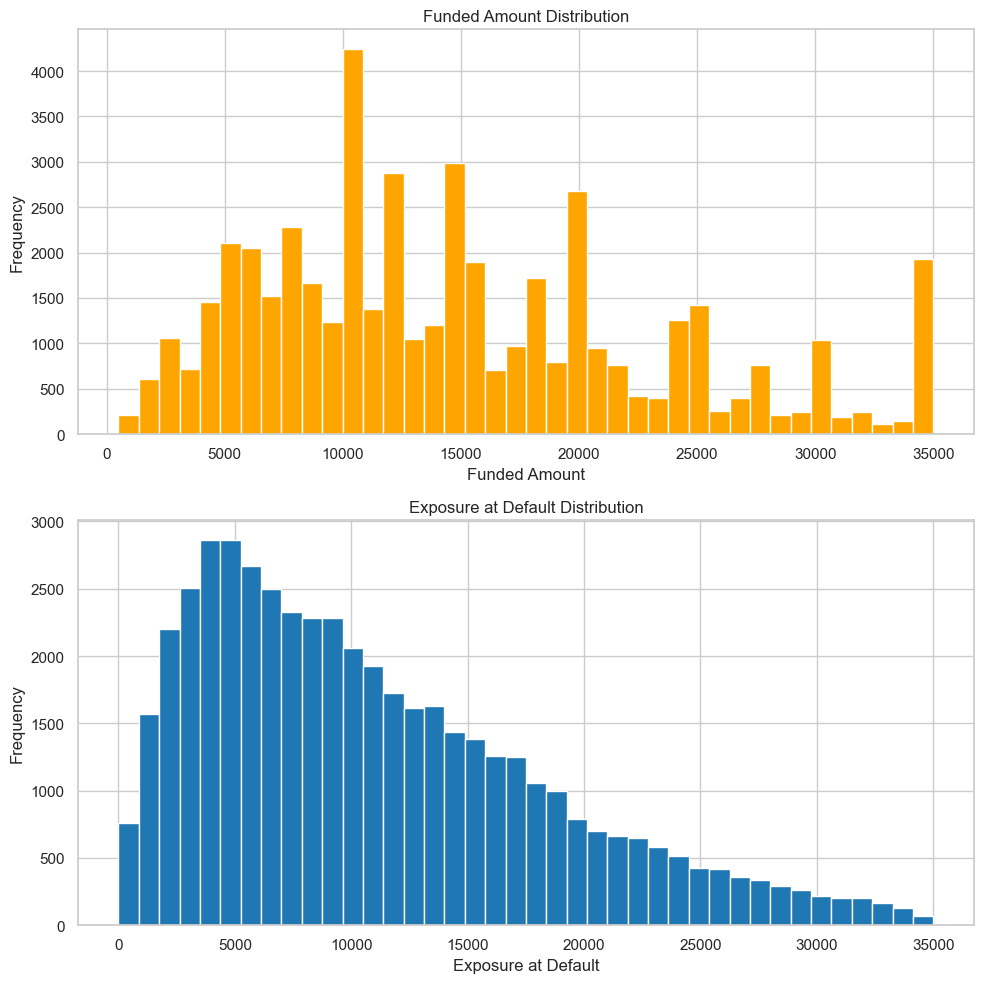

In [15]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot for ''funded_amnt''
axes[0].hist(default_loans['funded_amnt'], bins=40, color='orange')
axes[0].set_title('Funded Amount Distribution')
axes[0].set_xlabel('Funded Amount')
axes[0].set_ylabel('Frequency')

# Plot for 'Exposure_at_Default'
axes[1].hist(default_loans['exposure_at_default'], bins=40, color='#1f77b4')
axes[1].set_title('Exposure at Default Distribution')
axes[1].set_xlabel('Exposure at Default')
axes[1].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()


#### EAD Over Time — Annual EAD from 2007 to 2014

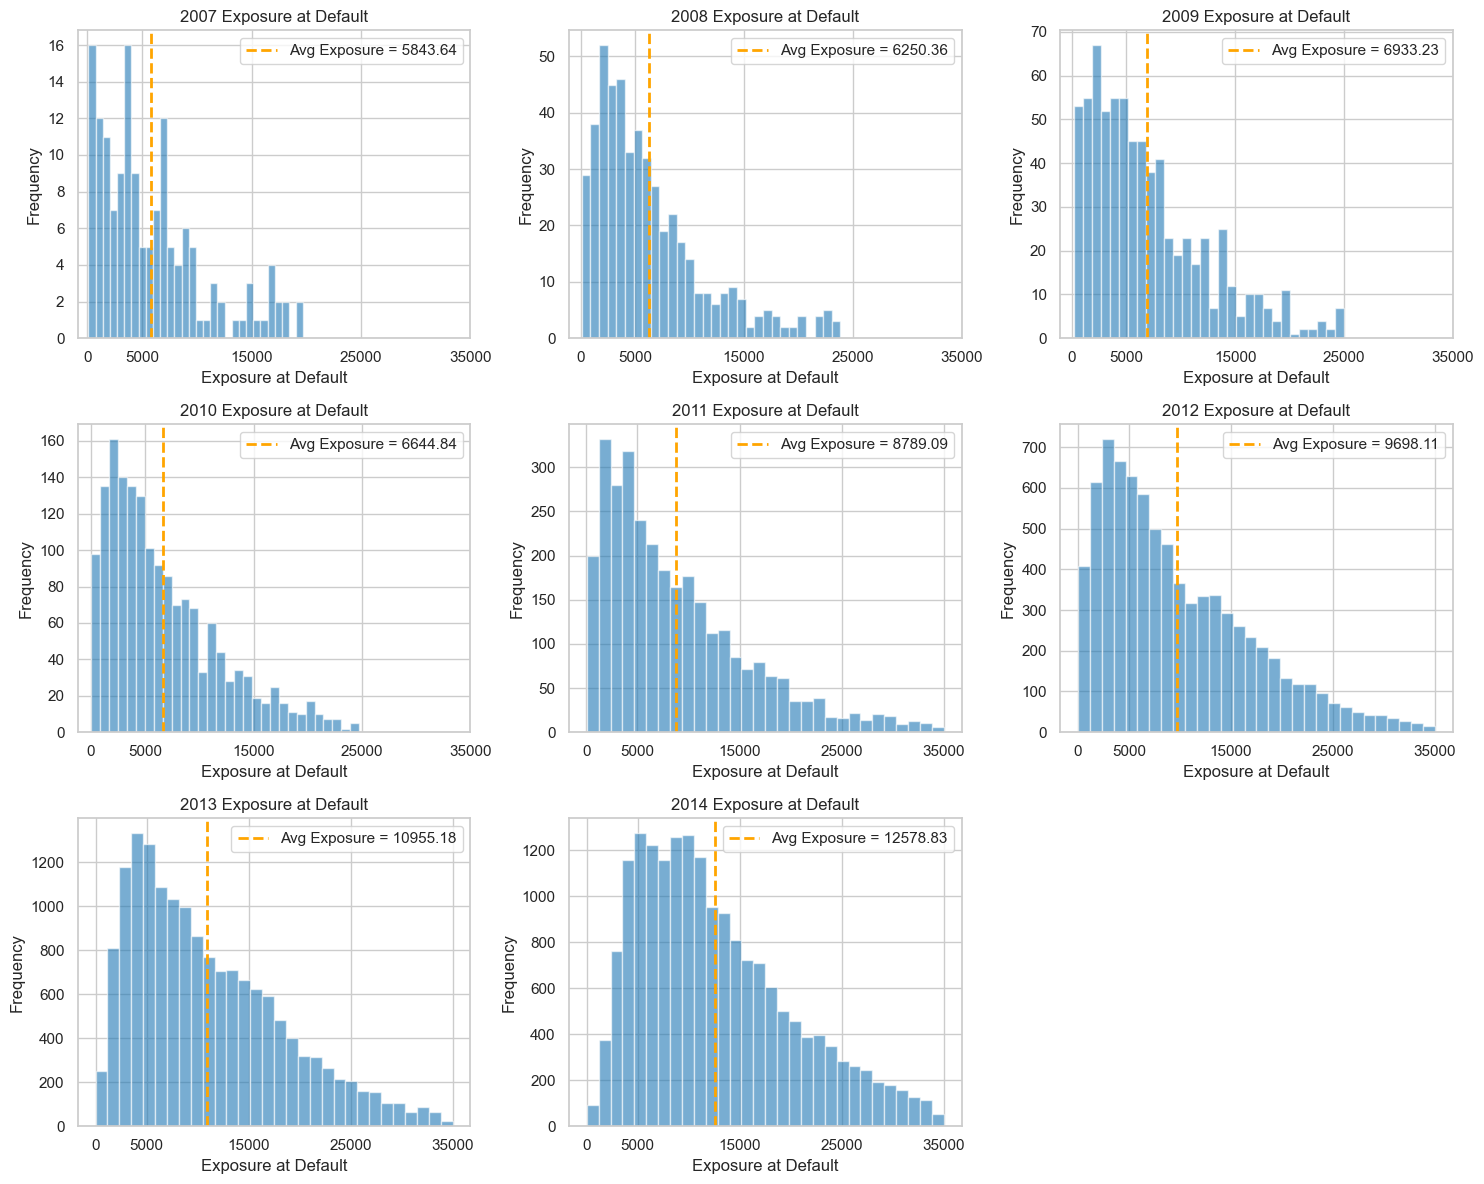

In [16]:
# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))

# Make axes a 2D array if only one row
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)
# If only one column, keep consistent shape
if n_cols == 1:
    axes = np.expand_dims(axes, axis=1)

# Plot for each year
for i, year in enumerate(years):
    row_idx = i // n_cols
    col_idx = i % n_cols
    ax = axes[row_idx, col_idx]

    # Filter data for the year
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    mask = (loan_df['issue_d'] >= start_date) & (loan_df['issue_d'] <= end_date)
    year_data = loan_df[mask]
    default_data = year_data[year_data['is_default'] == 1]

    # Plot histogram of 'exposure_at_default'
    ax.hist(default_data['exposure_at_default'], bins=30, alpha=0.6, color='#1f77b4')
    # Plot mean line
    avg_exp = default_data['exposure_at_default'].mean()
    ax.axvline(avg_exp, color='orange', linestyle='--', linewidth=2, label=f'Avg Exposure = {avg_exp:.2f}')
    ax.set_title(f'{year} Exposure at Default')
    ax.set_xlabel('Exposure at Default')
    ax.set_ylabel('Frequency')
    ax.set_xticks([0, 5000, 15000, 25000, 35000])  
    ax.legend()

# Remove any empty subplots (if total subplots > number of years)
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

- **Insights:**
  1. `funded_amnt` represents the total amount the borrower was funded with. The spikes at round numbers like \$10,000 and \$20,000 suggest that most loans are funded at these even numbers, likely due to loan size conventions or borrower preferences.

  2. The distribution of `EAD` is heavily right-skewed, with the highest frequency clustered around low to mid-range values (e.g., \$4,000 to \$10,000). The frequency diminishes sharply as the EAD increases, indicating fewer large residual balances at default.

  3. These patterns imply two key phenomena in the portfolio:
     - **Late-Stage Defaults Are Common:** Borrowers often make payments over several years, gradually paying down principal before encountering a financial shock (such as job loss or health issues). Defaults occurring in later years (e.g., year 4 of a 5-year loan) result in lower remaining EAD, even if the original loan amount was high.
     - **Early Defaults on Small Loans:** The lower end of the EAD distribution likely includes smaller loans that default early, leading to low residual balances.

  4. The EAD distribution shows slight variations over time, with more significant changes observed in 2013 and 2014, reflecting increases in the magnitude of residual balances during those years.

---

### 3.4 Univariate Analysis <a class="anchor" id="3d"></a>

- Categorical variables

In [17]:
# Check values counts of all categorical columns
for col in categorical_cols:
    print(f"Column Name: {col}")
    print(loan_df[col].value_counts())
    print("-----" * 10)

Column Name: grade
grade
B    130738
C    119384
D     73116
A     71754
E     34096
F     12662
G      3199
Name: count, dtype: int64
--------------------------------------------------
Column Name: sub_grade
sub_grade
B3    30262
B4    29136
C1    25676
C2    25500
B2    25397
C3    24130
B5    24058
C4    22961
B1    21885
C5    21117
A5    20901
D1    18298
A4    18225
D2    16231
D3    14159
D4    13430
A3    12019
D5    10998
A2    10505
A1    10104
E1     8587
E2     8292
E3     6639
E4     5739
E5     4839
F1     3748
F2     2877
F3     2596
F4     1983
F5     1458
G1     1059
G2      795
G3      565
G4      410
G5      370
Name: count, dtype: int64
--------------------------------------------------
Column Name: home_ownership
home_ownership
MORTGAGE    225858
RENT        180885
OWN          37983
OTHER          177
NONE            45
ANY              1
Name: count, dtype: int64
--------------------------------------------------
Column Name: verification_status
verification_stat

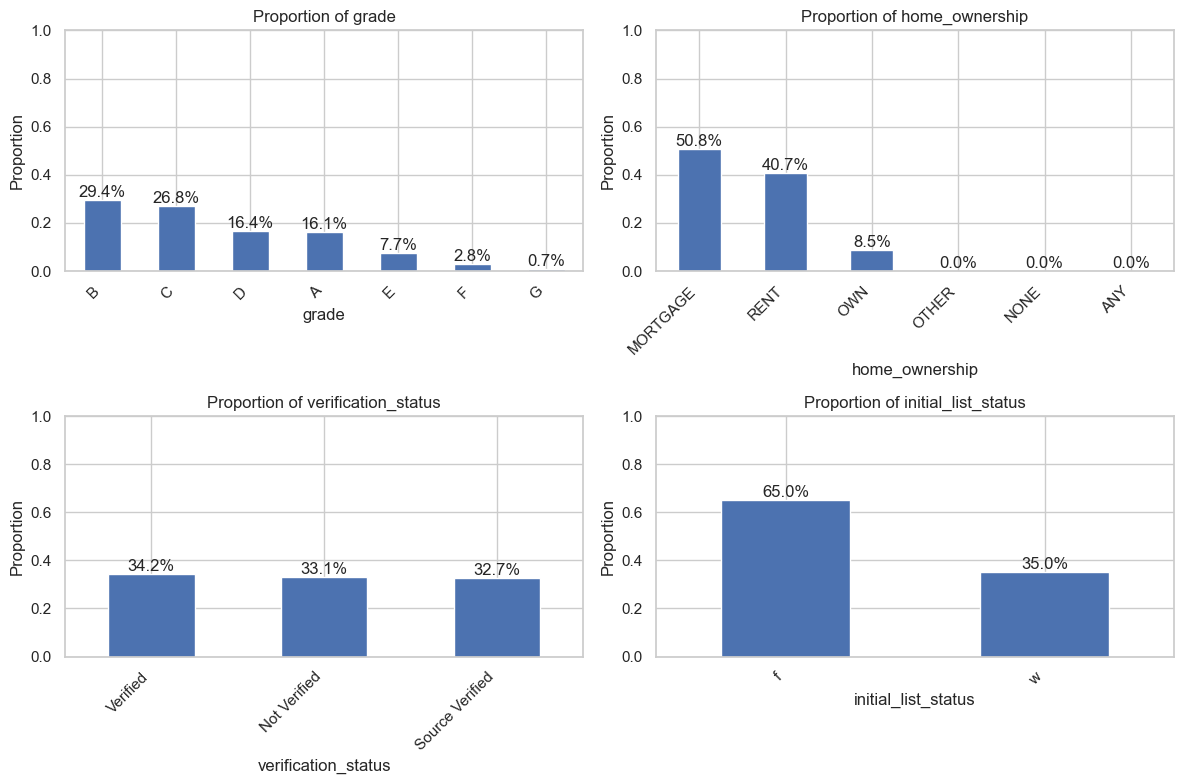

In [18]:
# Excluded columns for the subplots
excluded_cols = ['sub_grade', 'addr_state', 'purpose']
cols_to_plot = [col for col in categorical_cols if col not in excluded_cols]

# Optional: sort columns by their total count (descending)
counts = {col: len(loan_df[col]) for col in cols_to_plot}
sorted_cols = sorted(counts, key=counts.get, reverse=True)

# Number of plots per row
plots_per_row = 2
n_plots = len(sorted_cols)
n_rows = math.ceil(n_plots / plots_per_row)

# Create figure with subplots
fig, axes = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row*6, n_rows*4))
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)  # ensure 2D array

# Generate plots
for i, col in enumerate(sorted_cols):
    row_idx = i // plots_per_row
    col_idx = i % plots_per_row
    ax = axes[row_idx, col_idx]
    
    # Calculate proportions
    value_counts = loan_df[col].value_counts()
    proportions = value_counts / value_counts.sum()
    
    # Plot as bar chart
    bars = proportions.plot(kind='bar', ax=ax)
    
    # Annotate the bars with percentage labels
    for p in ax.patches:
        height = p.get_height()
        percentage = height * 100  # convert to percentage
        ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom')
    
    ax.set_title(f'Proportion of {col}')
    ax.set_ylabel('Proportion')
    ax.set_xlabel(col)
    ax.set_ylim(0, 1)  # just for clarity
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Remove any empty subplots if number of columns isn't a multiple of 2
total_subplots = n_rows * plots_per_row
for j in range(i + 1, total_subplots):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

- About 88.7% of users have a rating of D or higher, and remaining 11.3% has grade E or lower. The proportion is very simiar to the Fully Paid (89.2%) vs. (10.8%). The correlation should be further investigated. 
- About 60% of the borrowers own a house, and about 40% rent a house. The low values in other, none, any categories can be combined into one aggregated category.
- `initial_list_status` indicates how the loan was financed. 'F' (Fully Funded) loans were backed by many individual retail investors on the open marketplace. 'W' (Whole Loan) status means the loan was bought in bulk by a single large institutional investor.


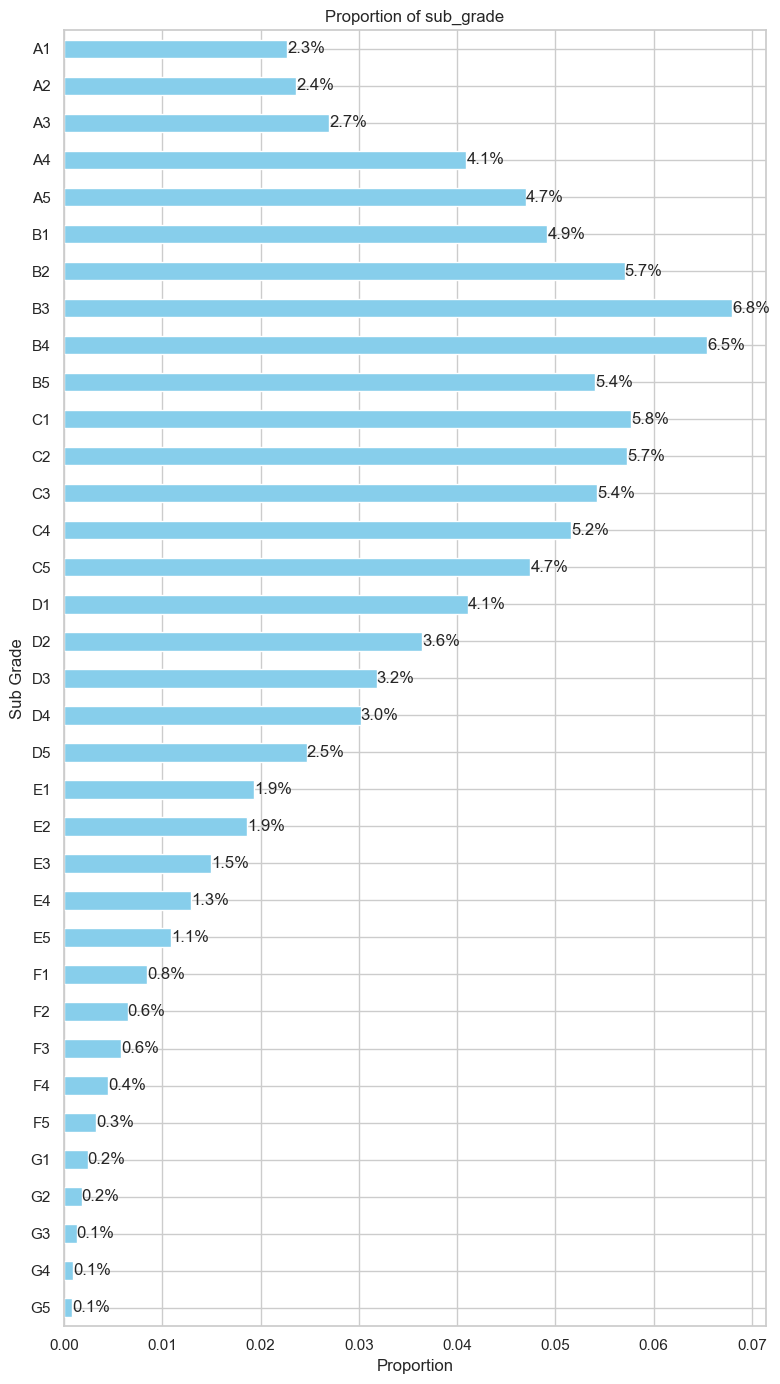

In [19]:
# Original order list
order = ['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5',
         'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5',
         'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5',
         'G1', 'G2', 'G3', 'G4', 'G5']

# To reverse the order
order_reversed = order[::-1]

# Calculate value counts as proportions
value_counts = loan_df['sub_grade'].value_counts(normalize=True)

# Reindex according to the reversed order
ordered_counts = value_counts.reindex(order_reversed)

# Plot
fig, ax = plt.subplots(figsize=(8, max(4, len(order_reversed)*0.4)))
ordered_counts.plot(kind='barh', ax=ax, color='skyblue')

# Add percentages on bars
for p in ax.patches:
    width = p.get_width()
    percentage = width * 100
    ax.annotate(f'{percentage:.1f}%', (width, p.get_y() + p.get_height() / 2),
                va='center', ha='left')

ax.set_title('Proportion of sub_grade')
ax.set_xlabel('Proportion')
ax.set_ylabel('Sub Grade')
plt.tight_layout()
plt.show()

- The distribution of `sub_grade` appears approximately normal. Since `sub_grade` provides a more granular rating over `grade`, including both could introduce multicollinearity in the model. Therefore, it may be prudent to drop either `grade` or `sub_grade` later.

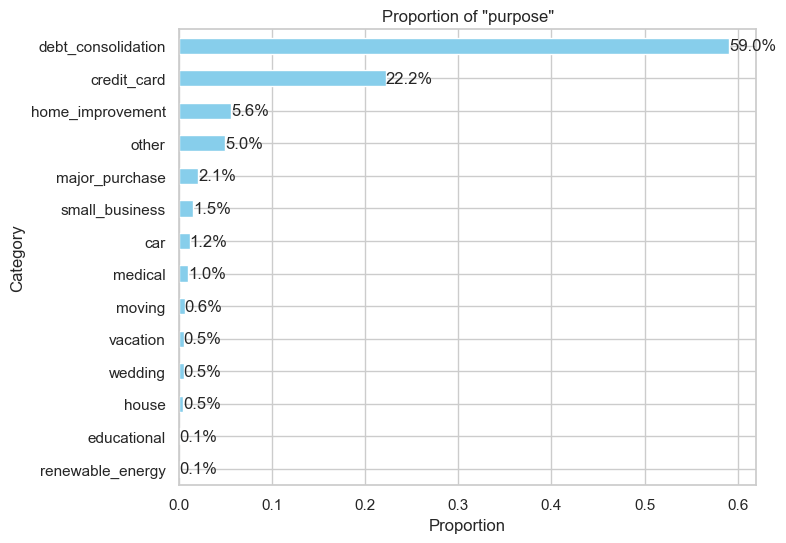

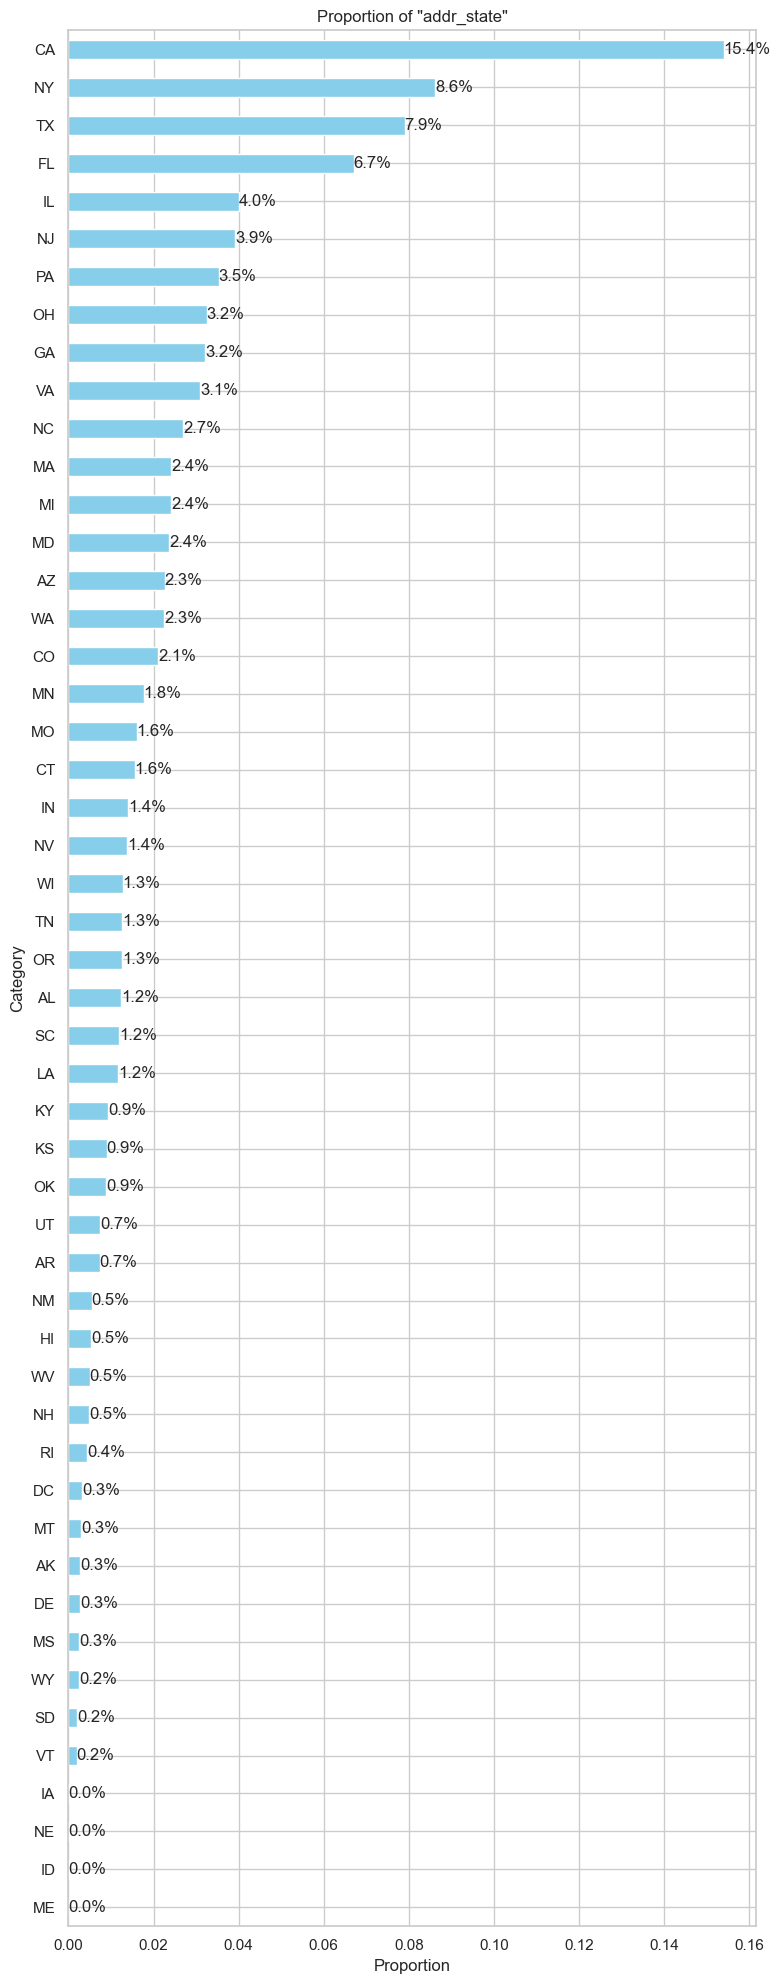

In [20]:
cols_to_plot = [ 'purpose', 'addr_state',]

# For each column, plot all categories
for col in cols_to_plot:
    # Calculate value counts as proportions and sort descending
    value_counts = loan_df[col].value_counts(normalize=True).sort_values()
    
    fig, ax = plt.subplots(figsize=(8, max(4, len(value_counts)*0.4)))  # Adjust height
    value_counts.plot(kind='barh', ax=ax, color='skyblue')
    
    # Add percentages on bars
    for p in ax.patches:
        width = p.get_width()
        percentage = width * 100
        ax.annotate(f'{percentage:.1f}%', (width, p.get_y() + p.get_height() / 2),
                    va='center', ha='left')
    
    ax.set_title(f'Proportion of "{col}"')
    ax.set_xlabel('Proportion')
    ax.set_ylabel('Category')
    plt.tight_layout()
    plt.show()

- Debt consolidation accounts for the majority of loan purposes at Lending Club. This typically involves borrowers taking out a new personal loan to pay off multiple existing, higher-interest debts. It could be worthwhile to examine the credit risk characteristics of loans with different purposes, as they may exhibit distinct risk profiles.

- The top states with the highest number of borrowers at Lending Club are California, New York, Texas, Florida, and Illinois.

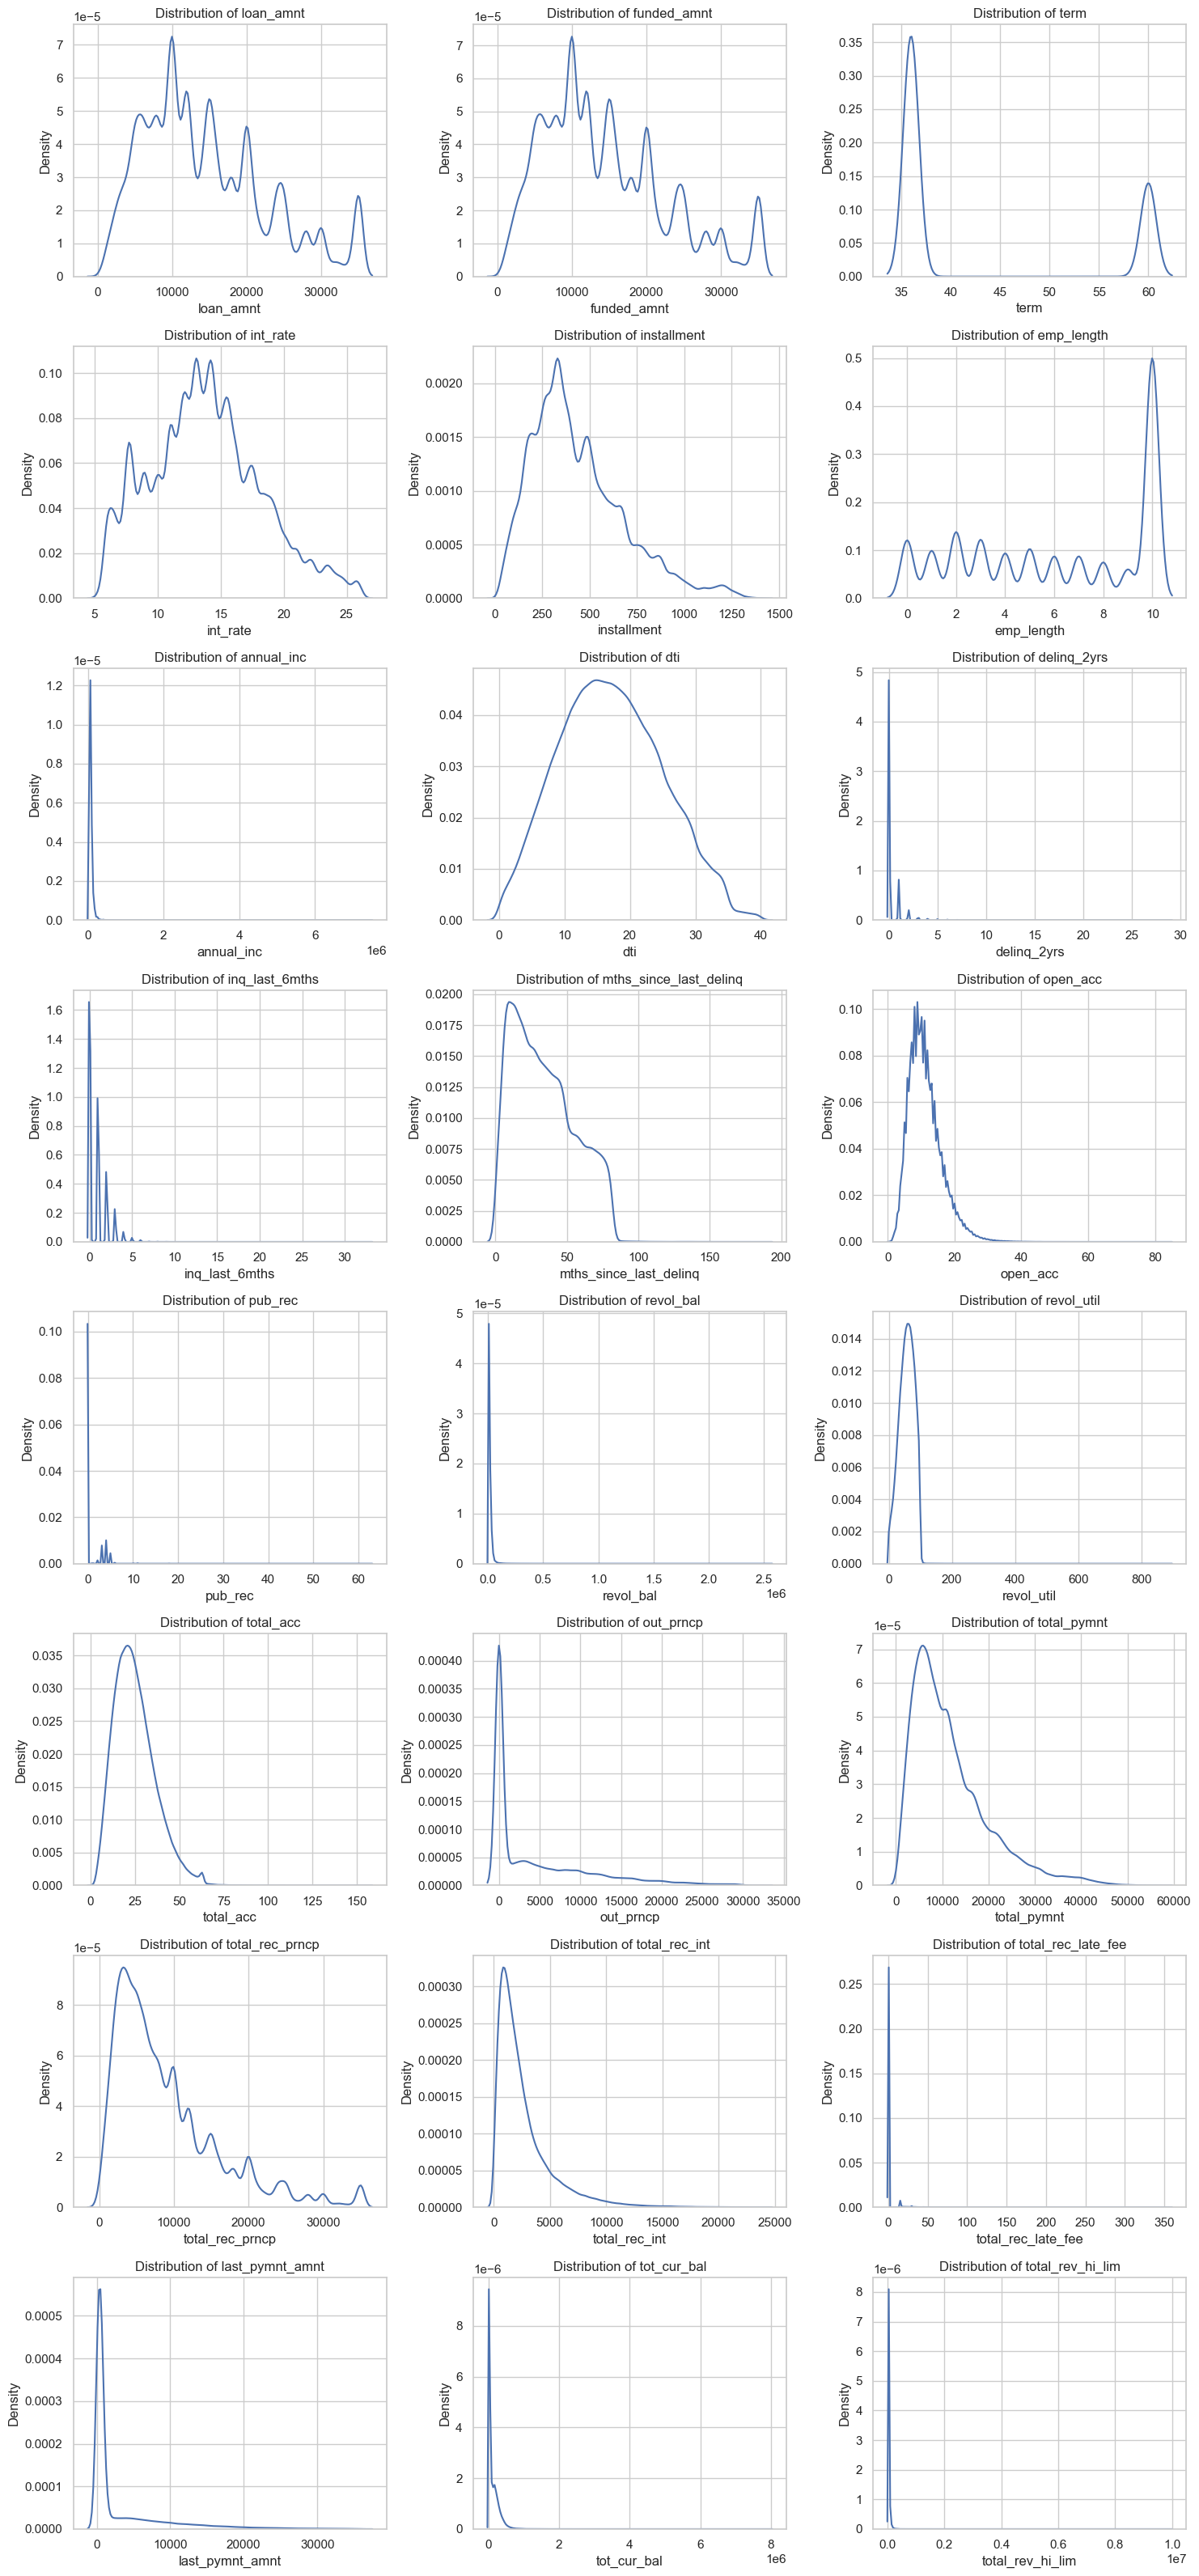

In [21]:
# Get the number of numerical features
num_features = len(numerical_cols)

# Calculate number of rows needed for 3 plots per row
n_cols = 3
n_rows = math.ceil(num_features / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))

# Ensure axes is 2D for consistent indexing
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)
if n_cols == 1:
    axes = np.expand_dims(axes, axis=1)

# Plot KDE for each feature
for i, feature in enumerate(numerical_cols):
    row_idx = i // n_cols
    col_idx = i % n_cols
    ax = axes[row_idx, col_idx]
    
    sns.kdeplot(loan_df[feature], ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')

# Remove empty subplots if any
total_subplots = n_rows * n_cols
for j in range(i + 1, total_subplots):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

- **Insights:**
  1. **`annual_inc`**: There are outliers indicating some borrowers report extremely high incomes.
  
  2. **`delinq_2yrs`, `inq_last_6_mths`, `pub_rec`, `total_rec_late_fee`**: These variables are highly right-skewed, which is understandable as they partly reflect the default profile, where a significant imbalance exists with 10.8% defaulted loans versus 89.2% fully paid.
  
  3. **`acc_open`, `inq_last_6mths`, `total_acc`**: These account-related features show some outliers with very large numbers, particularly in inquiries and total accounts opened.
  
  4. **`revol_bal`, `revol_util`, `total_rev_hi_lim`**: Revolving account variables exhibit extreme outliers, especially with some individuals having very high revolving credit limits, balances, or utilization rates. Utilizing `revol_bal / total_rev_hi_lim`, the utilization rate sometimes exceeds 800%, which warrants further investigation.
  
  5. **`out_prncp`, `total_pymnt`, `total_rec_prncp`, `last_pymnt_amount`, `tot_cur_bal`**: These dollar amount features related to loan performance are right-skewed, with most values concentrated at lower dollar amounts. The distribution aligns with the `loan_amnt` data, indicating that most loans are of moderate size, and the remaining balances or payments collected show similar skewness.


---

### 3.5 Outliers Analysis <a class="anchor" id="3e"></a>

Since I will build GLM models later, and these models are heavily impacted by outliers in predictors, it is crucial to examine and address outliers to seek optimal solutions.

- `annual_inc`

In [31]:
# Check outliers in annual income
loan_df[loan_df['annual_inc'] > 2000000]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
1290,8450,8450,36,12.2900,281.8400,C,C5,0,RENT,2039784.0000,Not Verified,2008-03-01,Fully Paid,debt_consolidation,FL,0.1300,0.0000,1.0000,0.0000,7.0000,0.0000,8747,51.8000,11.0000,f,0.0000,10144.1300,8450.0000,1694.1300,0.0000,0.0000,0.0000,293.0100,0.0000,0.0000,0,0.0000,0.0000
12133,5000,5000,36,12.7300,167.8400,C,C1,10,MORTGAGE,6000000.0000,Source Verified,2010-05-01,Fully Paid,home_improvement,CA,0.0100,0.0000,1.0000,80.0000,2.0000,0.0000,1434,37.7000,10.0000,f,0.0000,5511.8600,5000.0000,511.8600,0.0000,0.0000,0.0000,3845.2500,0.0000,0.0000,0,0.0000,0.0000
13164,25000,15500,60,10.6200,334.0800,B,B3,3,MORTGAGE,3900000.0000,Not Verified,2010-06-01,Fully Paid,home_improvement,NM,0.2000,0.0000,3.0000,NaN,12.0000,0.0000,3270,10.2000,32.0000,f,0.0000,20037.0187,15500.0000,4537.0200,0.0000,0.0000,0.0000,353.1400,0.0000,0.0000,0,0.0000,0.0000
90887,35000,35000,36,15.3100,1218.6100,C,C2,10,MORTGAGE,5000000.0000,Verified,2012-12-01,Fully Paid,credit_card,NY,2.3600,1.0000,2.0000,12.0000,13.0000,0.0000,975800,0.0000,36.0000,w,0.0000,43114.6300,35000.0000,8114.6300,0.0000,0.0000,0.0000,58.0300,8000078.0000,988000.0000,0,0.0000,0.0000
92041,14825,14825,36,13.1100,500.3000,B,B4,10,MORTGAGE,7141778.0000,Source Verified,2012-12-01,Fully Paid,debt_consolidation,GA,0.2500,0.0000,2.0000,26.0000,17.0000,0.0000,11351,70.9000,31.0000,w,0.0000,17229.3300,14825.0000,2404.3300,0.0000,0.0000,0.0000,8223.9300,69548.0000,16000.0000,0,0.0000,0.0000
106598,30000,30000,36,12.1200,998.1500,B,B3,10,MORTGAGE,6100000.0000,Verified,2013-02-01,Fully Paid,debt_consolidation,MD,0.2200,0.0000,0.0000,NaN,8.0000,0.0000,15219,94.5000,19.0000,w,0.0000,34146.1800,30000.0000,4146.1800,0.0000,0.0000,0.0000,18175.7800,329254.0000,16100.0000,0,0.0000,0.0000
258591,20000,20000,36,7.6200,623.2300,A,A3,5,RENT,7446395.0000,Source Verified,2014-02-01,Current,debt_consolidation,NY,0.1300,0.0000,0.0000,45.0000,10.0000,0.0000,24494,50.7000,24.0000,w,4130.5600,17911.0600,15869.4400,2041.6200,0.0000,0.0000,0.0000,623.2300,31691.0000,48300.0000,0,0.0000,0.0000
318406,20000,20000,60,12.9900,454.9600,C,C1,10,MORTGAGE,4560077.0000,Source Verified,2014-06-01,Current,debt_consolidation,UT,0.2500,0.0000,0.0000,NaN,11.0000,0.0000,15429,36.0000,19.0000,f,14999.5600,8644.2400,5000.4400,3643.8000,0.0000,0.0000,0.0000,454.9600,41434.0000,42800.0000,0,0.0000,0.0000
378244,15000,15000,36,19.5200,553.8000,E,E2,10,MORTGAGE,7500000.0000,Verified,2014-08-01,Current,medical,NV,0.2000,2.0000,5.0000,17.0000,29.0000,1.0000,9872,27.3000,42.0000,f,9393.6200,8860.8000,5606.3800,3254.4200,0.0000,0.0000,0.0000,553.8000,194985.0000,36200.0000,0,0.0000,0.0000
385648,15600,15600,36,7.6900,486.6200,A,A4,8,MORTGAGE,4900000.0000,Not Verified,2014-09-01,Fully Paid,debt_consolidation,IL,0.1100,1.0000,0.0000,4.0000,13.0000,0.0000,9015,26.1000,26.0000,f,0.0000,16184.9700,15600.0000,584.9700,0.0000,0.0000,0.0000,13751.8700,130235.0000,34600.0000,0,0.0000,0.0000


- Some of the values appear suspicious. For example, the borrower in the 4th row has a loan amount of \$35,000, a 36-month term, and an annual income of \$5,000,000. This implies an extremely low debt-to-income ratio, which is unlikely. Additionally, the borrower in the 2nd bottom position has an annual income exceeding \$7.5 million but holds a very low credit grade, raising further questions about data consistency or accuracy.
- I will fix this later to ensure such data does not affect the performance of the GLM models.

- `delinq_2yrs`, `inq_last_6mths`, `pub_rec`, `total_rec_late_fee`

In [34]:
loan_df[loan_df['delinq_2yrs'] > 20]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
117292,24000,24000,36,12.1200,798.5200,B,B3,5,RENT,98000.0000,Source Verified,2013-03-01,Current,debt_consolidation,MI,18.1600,24.0000,1.0000,15.0000,10.0000,0.0000,21461,44.3000,39.0000,f,1298.0200,27345.3800,22701.9800,4643.4000,0.0000,0.0000,0.0000,798.5200,45546.0000,48400.0000,0,0.0000,0.0000
132037,2500,2500,36,14.3300,85.8500,C,C1,1,RENT,51500.0000,Not Verified,2013-05-01,Fully Paid,credit_card,DC,10.1600,29.0000,0.0000,17.0000,23.0000,0.0000,5496,19.8000,55.0000,f,0.0000,2766.2677,2500.0000,266.2700,0.0000,0.0000,0.0000,46.6600,220646.0000,27700.0000,0,0.0000,0.0000
232487,10000,10000,36,13.9800,341.6800,C,C1,10,MORTGAGE,85000.0000,Not Verified,2014-01-01,Current,debt_consolidation,CA,18.5200,22.0000,3.0000,64.0000,11.0000,1.0000,4573,40.0000,63.0000,w,4099.7300,7858.6400,5900.2700,1958.3700,0.0000,0.0000,0.0000,341.6800,14734.0000,11500.0000,0,0.0000,0.0000
412274,7000,7000,36,9.1700,223.1600,B,B1,5,RENT,67260.0000,Not Verified,2014-10-01,Current,debt_consolidation,AL,14.9000,21.0000,0.0000,13.0000,25.0000,0.0000,4400,97.8000,46.0000,f,4314.2300,3366.0900,2685.7700,680.3200,0.0000,0.0000,0.0000,223.1600,171759.0000,4500.0000,0,0.0000,0.0000
431572,3500,3500,36,12.3900,116.9100,C,C1,2,RENT,32646.0000,Not Verified,2014-11-01,Late (31-120 days),debt_consolidation,SC,26.3600,21.0000,1.0000,6.0000,27.0000,0.0000,2965,9.4000,51.0000,f,2473.7500,1399.3100,1026.2500,373.0600,0.0000,0.0000,0.0000,116.9100,53634.0000,31500.0000,1,2473.7500,1.0000
453552,4000,4000,36,14.3100,137.3200,C,C4,2,RENT,50155.0000,Not Verified,2014-11-01,Fully Paid,credit_card,DC,12.2800,22.0000,1.0000,13.0000,17.0000,1.0000,3228,49.7000,36.0000,f,0.0000,4427.0600,4000.0000,427.0600,0.0000,0.0000,0.0000,3197.5400,121417.0000,6500.0000,0,0.0000,0.0000


In [39]:
loan_df[loan_df['inq_last_6mths'] > 25]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
486,3000,3000,36,13.7500,102.1700,E,E2,3,RENT,40000.0000,Not Verified,2007-12-01,Does not meet the credit policy. Status:Fully ...,debt_consolidation,CO,16.7100,0.0000,28.0000,0.0000,10.0000,0.0000,9135,76.8000,24.0000,f,0.0000,3677.5700,3000.0000,677.5700,0.0000,0.0000,0.0000,106.9800,0.0000,0.0000,0,0.0000,0.0000
509,3000,3000,36,12.1700,99.8900,D,D2,2,RENT,27228.0000,Not Verified,2007-12-01,Does not meet the credit policy. Status:Fully ...,moving,CO,14.8500,0.0000,31.0000,48.0000,2.0000,1.0000,0,0.0000,4.0000,f,0.0000,3594.1200,3000.0000,594.1200,0.0000,0.0000,0.0000,73.5400,0.0000,0.0000,0,0.0000,0.0000
512,4800,4800,36,10.2800,155.5200,C,C1,4,RENT,30000.0000,Not Verified,2007-12-01,Does not meet the credit policy. Status:Fully ...,small_business,WI,8.9600,0.0000,27.0000,0.0000,14.0000,0.0000,6893,15.4000,14.0000,f,0.0000,5599.8000,4800.0000,799.8000,0.0000,0.0000,0.0000,1.1800,0.0000,0.0000,0,0.0000,0.0000
1320,5100,5100,36,13.2400,172.4300,D,D3,0,RENT,17000.0000,Not Verified,2008-03-01,Does not meet the credit policy. Status:Charge...,credit_card,CT,6.9900,0.0000,32.0000,0.0000,4.0000,0.0000,5734,59.1000,22.0000,f,0.0000,688.0000,471.2100,216.7900,0.0000,0.0000,0.0000,172.4300,0.0000,0.0000,1,4628.7900,1.0000
1644,7000,7000,36,14.8200,242.0500,E,E3,0,MORTGAGE,45000.0000,Not Verified,2008-04-01,Does not meet the credit policy. Status:Charge...,debt_consolidation,OH,19.1200,0.0000,33.0000,47.0000,18.0000,0.0000,26531,52.6000,31.0000,f,0.0000,6080.5500,4521.9200,1528.6300,29.9981,0.0000,0.0000,499.1000,0.0000,0.0000,1,2478.0800,1.0000


In [37]:
loan_df[loan_df['pub_rec'] > 20]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
144118,10000,10000,36,15.3100,348.1800,C,C2,3,RENT,38750.0000,Source Verified,2013-06-01,Current,credit_card,WI,21.9900,0.0000,1.0000,NaN,15.0000,54.0000,10056,43.3000,31.0000,f,1676.4600,10793.6200,8323.5400,2470.0800,0.0000,0.0000,0.0000,349.0200,30978.0000,23200.0000,0,0.0000,0.0000
191335,7125,7125,36,13.6700,242.3800,B,B5,2,OWN,40000.0000,Verified,2013-10-01,Current,debt_consolidation,IN,14.1900,0.0000,0.0000,NaN,12.0000,49.0000,4636,12.1000,56.0000,w,2278.4200,6301.8800,4846.5800,1455.3000,0.0000,0.0000,0.0000,242.3800,16551.0000,38400.0000,0,0.0000,0.0000
232788,10000,10000,36,14.9800,346.5600,C,C3,10,RENT,50000.0000,Verified,2014-01-01,Current,debt_consolidation,IN,28.2500,0.0000,1.0000,NaN,8.0000,34.0000,10530,44.1000,11.0000,f,4134.8100,7970.8800,5865.1900,2105.6900,0.0000,0.0000,0.0000,346.5600,34708.0000,23900.0000,0,0.0000,0.0000
256755,35000,35000,36,16.2400,1234.6500,C,C5,10,MORTGAGE,500000.0000,Verified,2014-02-01,Current,credit_card,NY,2.7900,0.0000,1.0000,36.0000,12.0000,21.0000,13844,34.8000,21.0000,f,14627.4000,28396.9500,20372.6000,8024.3500,0.0000,0.0000,0.0000,1234.6500,368848.0000,39800.0000,0,0.0000,0.0000
257665,8000,8000,36,12.9900,269.5200,B,B5,9,OWN,37000.0000,Source Verified,2014-02-01,Current,home_improvement,IN,3.5700,0.0000,0.0000,NaN,4.0000,63.0000,2185,27.7000,7.0000,w,3483.5800,5929.4400,4516.4200,1413.0200,0.0000,0.0000,0.0000,269.5200,2185.0000,7900.0000,0,0.0000,0.0000
290170,5950,5950,36,23.4300,231.6600,F,F1,4,RENT,31000.0000,Verified,2014-04-01,Current,small_business,WI,33.6000,0.0000,1.0000,NaN,16.0000,40.0000,2174,9.1000,30.0000,f,2987.2100,4864.8600,2962.7900,1902.0700,0.0000,0.0000,0.0000,231.6600,28433.0000,23900.0000,0,0.0000,0.0000


In [41]:
loan_df[loan_df['total_rec_late_fee'] > 200]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
6310,20000,20000,36,20.1700,745.0100,G,G2,0,RENT,240000.0000,Verified,2009-09-01,Does not meet the credit policy. Status:Fully ...,debt_consolidation,IL,6.4600,0.0000,9.0000,NaN,8.0000,0.0000,29182,97.9000,12.0000,f,0.0000,27370.9300,20000.0000,7162.1100,208.8195,0.0000,0.0000,1009.4000,0.0000,0.0000,0,0.0000,0.0000
70231,35000,35000,36,19.0500,1283.8500,D,D4,0,RENT,125000.0000,Source Verified,2012-08-01,Fully Paid,debt_consolidation,NY,11.0100,0.0000,0.0000,NaN,8.0000,0.0000,1063,88.6000,22.0000,f,0.0000,47080.9143,35000.0000,11794.1700,286.7476,0.0000,0.0000,296.8200,0.0000,0.0000,0,0.0000,0.0000
190318,25000,25000,36,19.2000,918.9400,D,D3,0,MORTGAGE,175000.0000,Verified,2013-10-01,Current,moving,OR,9.3700,2.0000,1.0000,5.0000,17.0000,0.0000,14455,53.3000,41.0000,f,7715.3700,25036.5700,17284.6300,7522.1900,229.7500,0.0000,0.0000,1883.8300,466024.0000,27100.0000,0,0.0000,0.0000
195238,35000,35000,60,25.8900,1045.6400,G,G3,10,MORTGAGE,120000.0000,Source Verified,2013-10-01,Charged Off,debt_consolidation,FL,27.7400,2.0000,1.0000,6.0000,17.0000,0.0000,18081,74.1000,43.0000,w,0.0000,21971.9600,3418.5200,12793.1900,358.6800,5401.5700,972.2826,1078.2900,263171.0000,24400.0000,1,31581.4800,0.8598
198968,20000,20000,36,15.6100,699.3000,C,C3,0,MORTGAGE,75000.0000,Verified,2013-10-01,Charged Off,debt_consolidation,TX,32.9600,1.0000,0.0000,6.0000,16.0000,0.0000,30077,68.0000,39.0000,f,0.0000,14224.4800,8913.6900,5016.1100,294.6800,0.0000,0.0000,3030.9600,97432.0000,44200.0000,1,11086.3100,1.0000
221170,27050,27050,36,16.2400,954.2100,C,C5,3,RENT,65000.0000,Source Verified,2013-12-01,Late (31-120 days),debt_consolidation,CA,22.8000,0.0000,0.0000,29.0000,10.0000,0.0000,8151,89.6000,16.0000,f,12363.7700,21261.0000,14686.2300,6306.2200,268.5500,0.0000,0.0000,1001.9200,43918.0000,9100.0000,1,12363.7700,1.0000
265587,16000,16000,36,12.9900,539.0300,B,B5,4,MORTGAGE,135000.0000,Source Verified,2014-03-01,Charged Off,home_improvement,VA,12.5300,0.0000,0.0000,26.0000,7.0000,0.0000,7309,50.4000,18.0000,w,0.0000,10472.2400,7783.5400,2446.1500,242.5500,0.0000,0.0000,1025.0000,291870.0000,14500.0000,1,8216.4600,1.0000
291687,16800,16800,60,14.6400,396.5100,C,C3,10,MORTGAGE,105000.0000,Not Verified,2014-04-01,Charged Off,credit_card,NJ,25.2300,0.0000,1.0000,NaN,28.0000,0.0000,39645,38.8000,45.0000,w,0.0000,8582.5500,5206.7300,3162.5200,213.3000,0.0000,0.0000,689.2800,114641.0000,102200.0000,1,11593.2700,1.0000
396834,35000,35000,60,25.5700,1039.0300,F,F5,0,MORTGAGE,100000.0000,Verified,2014-10-01,Current,debt_consolidation,NC,28.0800,0.0000,2.0000,NaN,8.0000,0.0000,31859,88.0000,45.0000,f,30340.6200,14796.1200,4659.3800,9883.9400,252.8000,0.0000,0.0000,1340.2300,258454.0000,36200.0000,0,0.0000,0.0000


- No signs of data error were found. I will use the common approaches like IQR to fix such outliers.

- `revol_bal`, `revol_util`, `total_rev_hi_lim`

In [46]:
loan_df[loan_df['total_rev_hi_lim'] > 0.3e7]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
147627,28000,28000,36,8.9000,889.0900,A,A5,1,MORTGAGE,1000000.0000,Verified,2013-06-01,Current,credit_card,CT,12.5400,0.0000,2.0000,39.0000,13.0000,0.0000,2568995,20.4000,28.0000,f,4351.8100,27557.2300,23648.1900,3909.0400,0.0000,0.0000,0.0000,889.0900,3881449.0000,9999999.0000,0,0.0000,0.0000
420627,26200,26200,36,7.6900,817.2800,A,A4,3,MORTGAGE,999999.0000,Verified,2014-10-01,Current,debt_consolidation,CT,13.3000,0.0000,0.0000,54.0000,16.0000,0.0000,2560703,16.3000,31.0000,f,16009.9500,12259.2000,10190.0500,2069.1500,0.0000,0.0000,0.0000,817.2800,3840795.0000,9999999.0000,0,0.0000,0.0000


The 9,999,999 number in revoling credit limit seem suspicious, especially when their loan amount was less than 30,000. 

In [48]:
loan_df[loan_df['revol_bal'] > 1.5e6]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
100440,35000,35000,36,11.1400,1148.1800,B,B2,10,MORTGAGE,400000.0000,Verified,2013-01-01,Fully Paid,debt_consolidation,FL,33.4800,0.0000,4.0000,NaN,28.0000,0.0000,1743266,29.5000,59.0000,f,0.0000,35951.8000,35000.0000,951.8000,0.0000,0.0000,0.0000,33656.7000,3471522.0000,2013133.0000,0,0.0000,0.0000
147627,28000,28000,36,8.9000,889.0900,A,A5,1,MORTGAGE,1000000.0000,Verified,2013-06-01,Current,credit_card,CT,12.5400,0.0000,2.0000,39.0000,13.0000,0.0000,2568995,20.4000,28.0000,f,4351.8100,27557.2300,23648.1900,3909.0400,0.0000,0.0000,0.0000,889.0900,3881449.0000,9999999.0000,0,0.0000,0.0000
206638,35000,35000,36,14.3000,1201.3300,C,C1,10,MORTGAGE,400000.0000,Verified,2013-11-01,Charged Off,other,FL,32.8000,0.0000,3.0000,NaN,28.0000,0.0000,1746716,38.6000,55.0000,f,0.0000,34268.4000,29874.4300,4393.9700,0.0000,0.0000,0.0000,1201.3300,3437283.0000,1998700.0000,1,5125.5700,1.0000
420627,26200,26200,36,7.6900,817.2800,A,A4,3,MORTGAGE,999999.0000,Verified,2014-10-01,Current,debt_consolidation,CT,13.3000,0.0000,0.0000,54.0000,16.0000,0.0000,2560703,16.3000,31.0000,f,16009.9500,12259.2000,10190.0500,2069.1500,0.0000,0.0000,0.0000,817.2800,3840795.0000,9999999.0000,0,0.0000,0.0000


In [50]:
loan_df[loan_df['revol_util'] > 200]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,tot_cur_bal,total_rev_hi_lim,is_default,exposure_at_default,loss_given_default
278667,3500,3500,36,12.4900,117.0800,B,B4,10,RENT,45000.0000,Verified,2014-04-01,Fully Paid,debt_consolidation,CA,14.6700,0.0000,0.0000,67.0000,2.0000,0.0000,2677,892.3000,9.0000,f,0.0000,3944.6600,3500.0000,444.6600,0.0000,0.0000,0.0000,2422.6200,5668.0000,300.0000,0,0.0000,0.0000
317285,16500,16500,60,14.4900,388.1400,C,C4,0,MORTGAGE,48000.0000,Source Verified,2014-06-01,In Grace Period,debt_consolidation,NC,9.3300,0.0000,0.0000,NaN,4.0000,0.0000,2566,366.6000,15.0000,f,12727.2300,6986.5200,3772.7700,3213.7500,0.0000,0.0000,0.0000,388.1400,17390.0000,700.0000,0,0.0000,0.0000


Revolving utilization is defined as: $\text{Revolving Utilization} = \frac{\text{Total Revolving Balance}}{\text{Total Revolving Credit Limit}}$. The should is usually bounded between 0-100%, with over 100% as a sign of overdraft. These two data has utilization rate over 300% and 800% percent, which seems suspicious.

---

### 3.6 Multivariate Analysis <a class="anchor" id="3f"></a>

#### 3.6.1 Correlation Heatmap  <a class="anchor" id="3f1"></a>

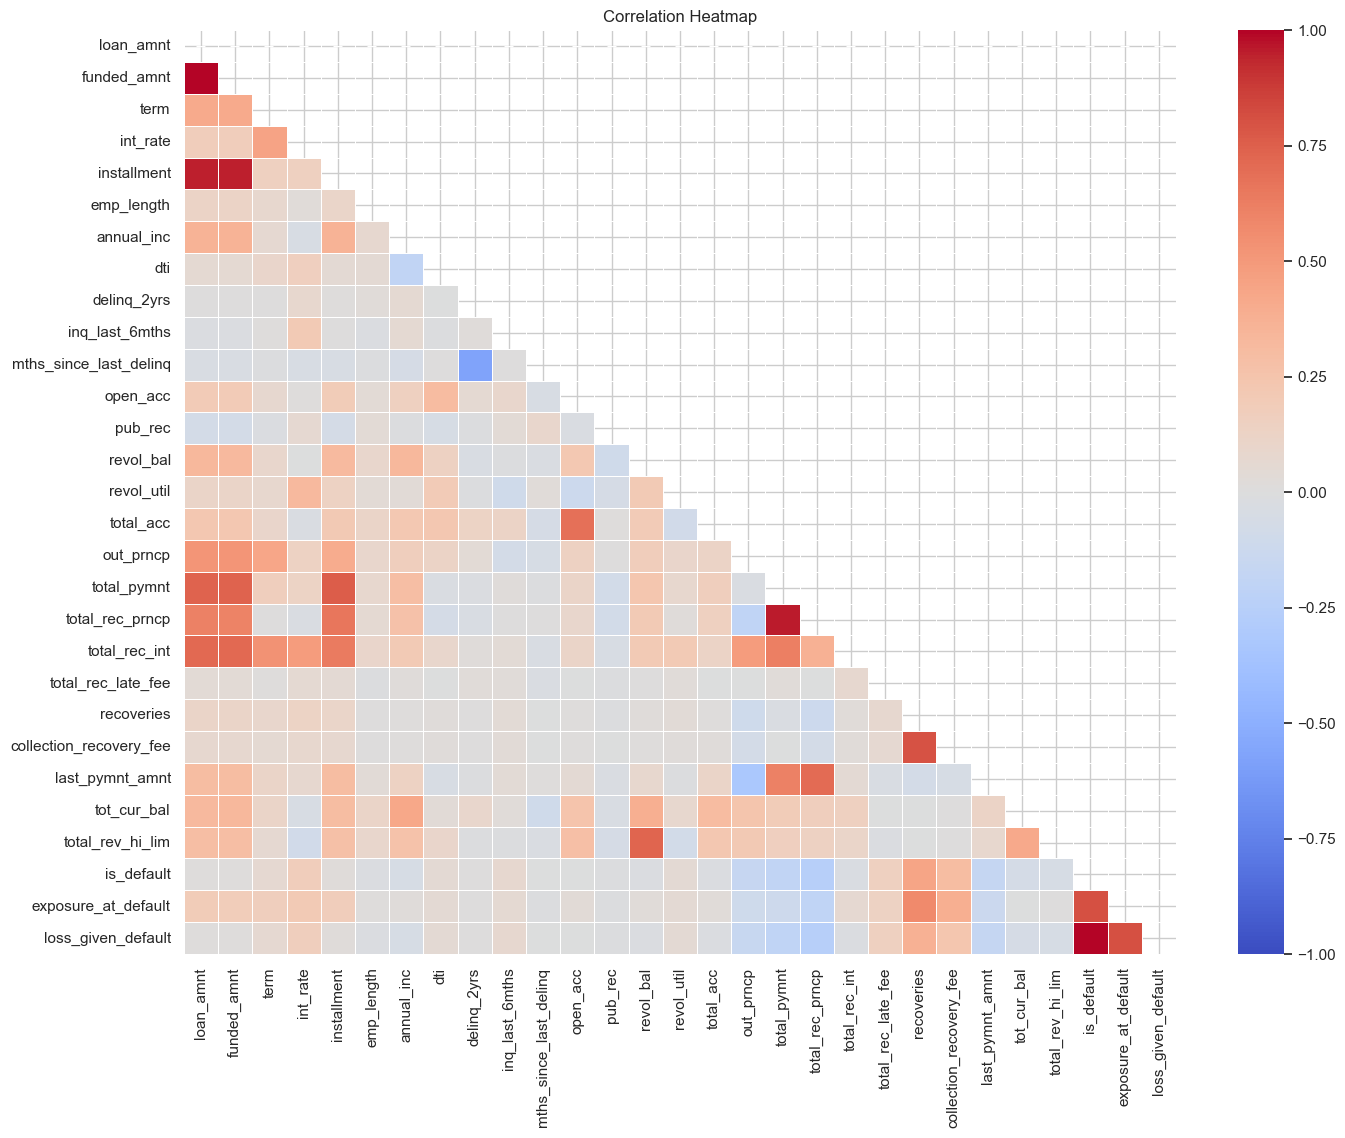

In [67]:
# Extract the subset of the DataFrame
num_cols = loan_df.select_dtypes(include='number').columns.tolist()
corr_matrix = loan_df[num_cols].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set plot size
plt.figure(figsize=(16, 12))

# Plot the heatmap
sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap='coolwarm', 
            annot=True, 
            fmt='.2f', 
            vmin=-1, 
            vmax=1, 
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

- Insights:
    1. `funded_amnt` and `loan_amnt` are highly correlated, as both represent the principal amount of the loan, with differences primarily related to the timing of the funding.

    2. `installment` shows strong correlation with both `funded_amnt` and `loan_amnt`, as it is calculated directly based on the principal amount.

    3. `total_rec_prncp` (total principal received to date) and `total_pymnt` (total payments received) are highly correlated because: $\mathbf{\text{Total Payments}} = \mathbf{\text{Principal}} + \mathbf{\text{Interest}} + \mathbf{\text{Fees}}$. This indicates potential multicollinearity among `total_pymnt`, `total_rec_prncp`, and `total_rec_int`, which should be addressed in further modeling.

    4. `total_acc` and `open_acc` both represents the number of accounts borrower have. The high correlation indicates that we need to drop one of the features.

    5. The correlation among target variables (like `is_default`, `recoveries`, `cillection_recovery_fee` etc.) is less relevant because they will typically be removed from predictor sets during feature selection and modeling.

---

#### 3.6.1 Borrower Attributes  <a class="anchor" id="3f2"></a>


This section will explore the correlation between Probability of Default (PD) and Loss Given Default (LGD) with various borrower characteristics.

In [ ]:
# Create a copy for data visualization
plot_df = loan_df.copy()

- `grade`

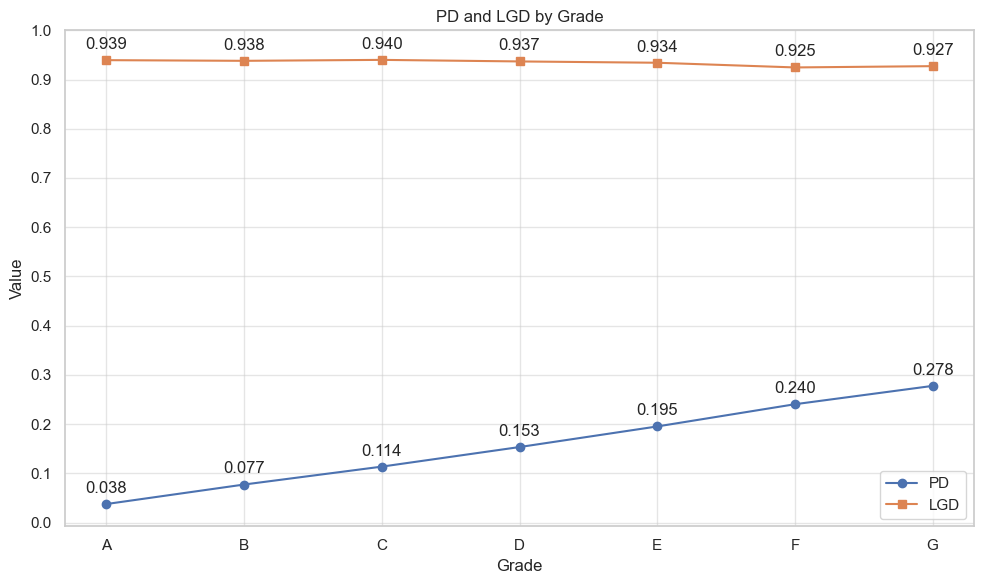

In [153]:
# Calculate PD and LGD by grade
pd_by_grade = loan_df.groupby('grade')['is_default'].mean()
default_loans = loan_df[loan_df['is_default'] == 1]
avg_lgd_by_grade = default_loans.groupby('grade')['loss_given_default'].mean()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(pd_by_grade.index, pd_by_grade.values, marker='o', label='PD', linestyle='-')
plt.plot(avg_lgd_by_grade.index, avg_lgd_by_grade.values, marker='s', label='LGD', linestyle='-')

# Add number labels with 3 decimal places
for x, y in zip(pd_by_grade.index, pd_by_grade.values):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_by_grade.index, avg_lgd_by_grade.values):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

# Final touches
plt.xlabel('Grade')
plt.ylabel('Value')
plt.title('PD and LGD by Grade')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

- **Insights:**
    1. The plots clearly demonstrate that `grade` influences PD. Lower-grade ratings correspond to higher probabilities of default.
    2. LGD is relatively consistent across all grades


- `sub_grade`

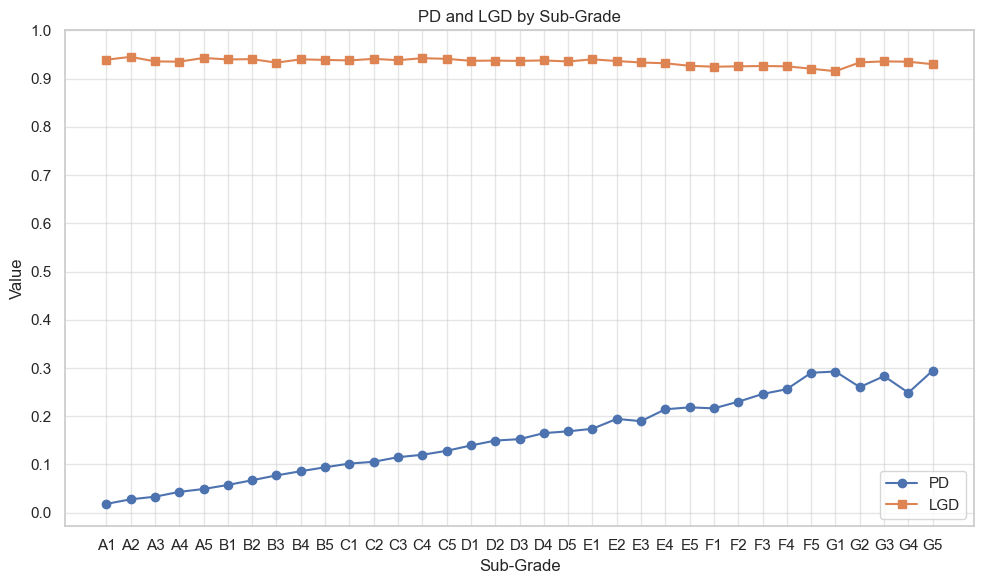

In [155]:
# Calculate PD by sub_grade, sorted by sub_grade order
pd_by_subgrade = loan_df.groupby('sub_grade')['is_default'].mean()

# Calculate LGD by sub_grade, ONLY on default loans
default_loans = loan_df[loan_df['is_default'] == 1]
avg_lgd_by_subgrade = default_loans.groupby('sub_grade')['loss_given_default'].mean()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(pd_by_subgrade.index, pd_by_subgrade.values, marker='o', label='PD', linestyle='-')
plt.plot(avg_lgd_by_subgrade.index, avg_lgd_by_subgrade.values, marker='s', label='LGD', linestyle='-')

plt.xlabel('Sub-Grade')
plt.ylabel('Value')
plt.title('PD and LGD by Sub-Grade')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

- **Insights:**

  As expected, the correlations between `sub_grade` and both PD and LGD are consistent with those observed for `grade`. This consistency suggests that, during modeling, it may be sufficient to include only one of these features to avoid redundancy and multicollinearity.

- `annual_inc`

In [ ]:
# Define the function to categorize annual income
def categorize_income(amount):

    if amount < 25000:
        return 'Low (<$25K)'
    elif amount < 50000:
        return 'Moderate ($25K-$50K)'
    elif amount < 75000:
        return 'Average ($50K-$75K)'
    elif amount < 100000:
        return 'Above Average ($75K-$100K)'
    elif amount < 150000:
        return 'High ($100K-$150K)'
    else:  # amount >= 150000
        return 'Very High (>$150K)'

# Apply the function to create the new income category column
plot_df['annual_inc_category'] = plot_df['annual_inc'].apply(categorize_income)

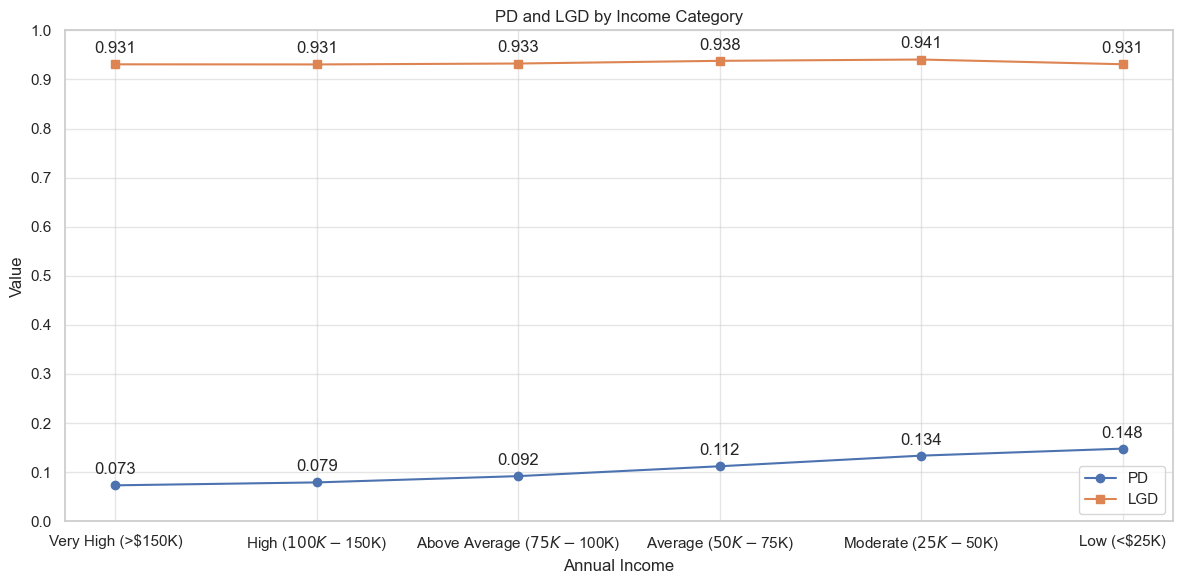

In [ ]:
# Calculate PD and LGD by income category
pd_by_income = plot_df.groupby('annual_inc_category')['is_default'].mean()
default_loans = plot_df[plot_df['is_default'] == 1]
avg_lgd_by_income = default_loans.groupby('annual_inc_category')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_income.sort_values()
avg_lgd_reindexed = avg_lgd_by_income.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add number labels with :.3f
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Annual Income')
plt.ylabel('Value')
plt.title('PD and LGD by Income Category')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

**Insights:**

1. The data suggests an inverse correlation between annual income and PD: as income decreases, PD increases.

- `verification_status`

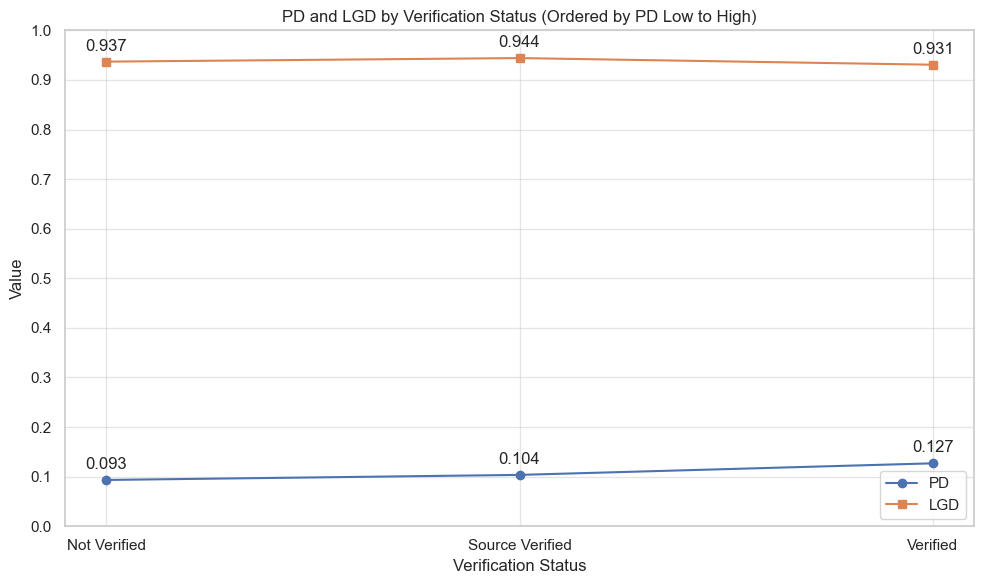

In [ ]:
# Calculate PD and LGD by verification_status directly from the full dataset
pd_by_verification = loan_df.groupby('verification_status')['is_default'].mean()
default_loans_verification = loan_df[loan_df['is_default'] == 1]
avg_lgd_by_verification = default_loans_verification.groupby('verification_status')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_verification.sort_values()
avg_lgd_reindexed = avg_lgd_by_verification.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add number annotations with three decimal places
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

# Final details
ax.set_xlabel('Verification Status')
ax.set_ylabel('Value')
ax.set_title('PD and LGD by Verification Status (Ordered by PD Low to High)')
ax.legend()
ax.set_yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

- **Insights:**

  1. Interestingly, borrowers with verifired income actually has a higher PD, which contradicts the business intuition.

- `emp_length`

In [ ]:
# Convert emp_length to str for visualization purpose
plot_df['emp_length'] = plot_df['emp_length'].astype(str)

# Replace the '10+ years' back for visualization
plot_df['emp_length'] = plot_df['emp_length'].str.replace('10', '10 or 10+ years')

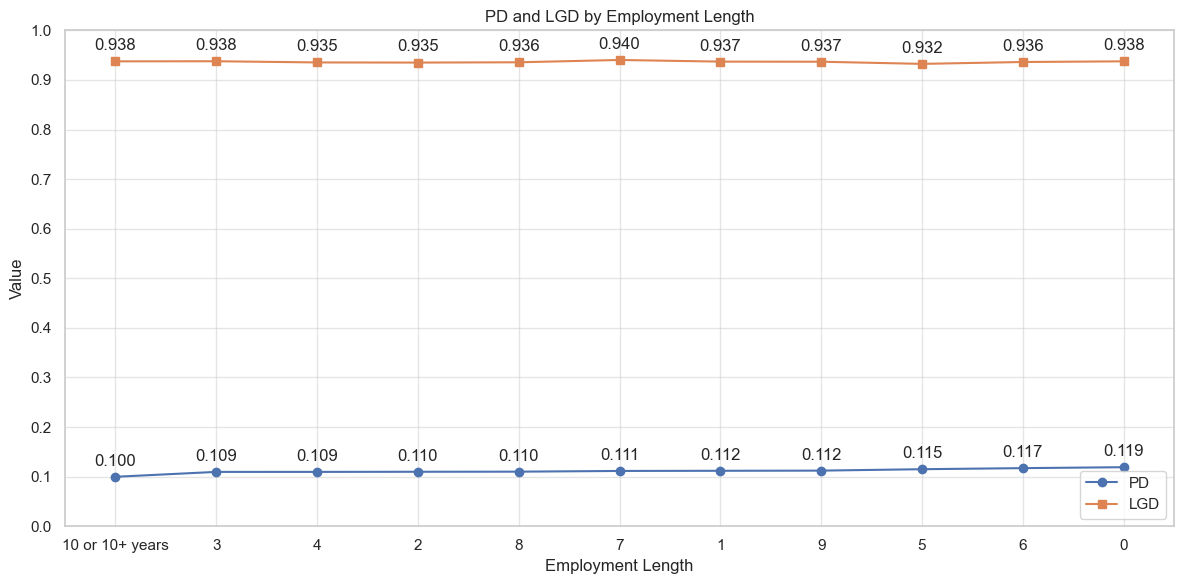

In [ ]:
# Calculate PD and LGD by emp_length category
pd_by_emp_length = plot_df.groupby('emp_length')['is_default'].mean()
default_loans = plot_df[plot_df['is_default'] == 1]
avg_lgd_by_emp_length = default_loans.groupby('emp_length')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_emp_length.sort_values()
avg_lgd_reindexed = avg_lgd_by_emp_length.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add number labels with :.3f
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Employment Length')
plt.ylabel('Value')
plt.title('PD and LGD by Employment Length')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

- **Insights:**

    The relationship between employment length and the PD is not strictly linear.

    Lowest Risk: Borrowers with 10 or more years of employment demonstrate the highest job stability, correlating with the lowest PD

    Highest Risk: Borrowers who have never worked or have less than one year of employment exhibit the lowest stability, correlating with the highest PD.


- `home_ownership`

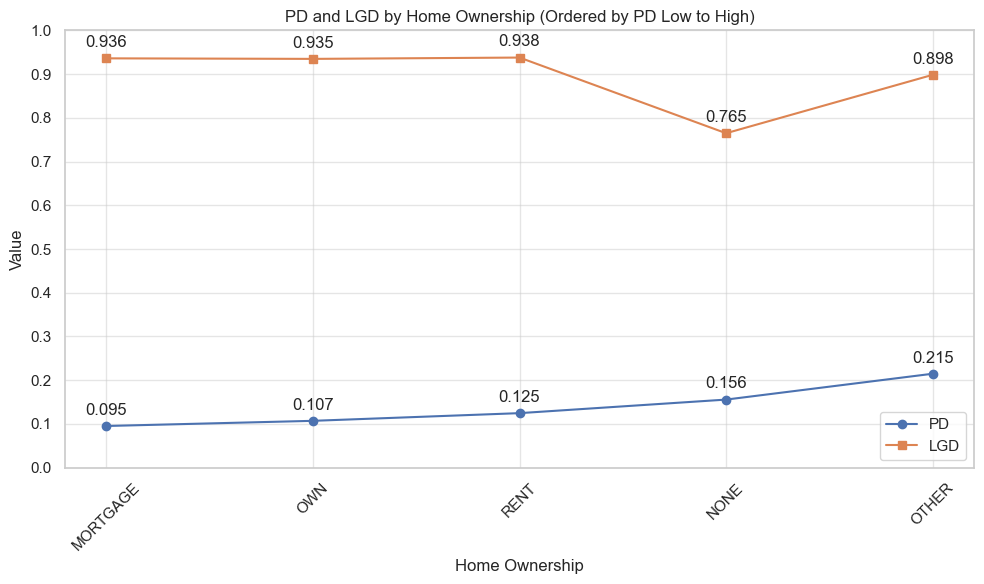

In [ ]:
# Filter out 'ANY' category for this analysis only
loan_df_filtered = loan_df[loan_df['home_ownership'] != 'ANY']

# Calculate PD and LGD using the filtered data
pd_by_home = loan_df_filtered.groupby('home_ownership')['is_default'].mean()
default_loans = loan_df_filtered[loan_df_filtered['is_default'] == 1]
avg_lgd_by_home = default_loans.groupby('home_ownership')['loss_given_default'].mean()

# Order by PD ascending
ordered_pd = pd_by_home.sort_values()
ordered_lgd = avg_lgd_by_home.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(ordered_lgd.index, ordered_lgd.reindex(ordered_pd.index).values, marker='s', label='LGD', linestyle='-')

# Add number labels with .3f precision on each dot
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

for x, y in zip(ordered_lgd.reindex(ordered_pd.index).index, ordered_lgd.reindex(ordered_pd.index).values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

# Finalize
ax.set_xlabel('Home Ownership')
ax.set_ylabel('Value')
ax.set_title('PD and LGD by Home Ownership (Ordered by PD Low to High)')
ax.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
ax.set_xticklabels(ordered_pd.index, rotation=45)
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

- **Insights:**

  1. From previous univariate analysis, we observed that the `NONE` and `OTHER` groups have very few data points, which may not be representative of the overall population. When comparing PD across `Mortgage`, `Own`, and `Rent` groups, borrowers who own a house tend to have slightly lower PD than those who do not own a house.
  
  2. LGD values are relatively similar across groups when excluding the `NONE` and `OTHER` categories.

- `addr_state`

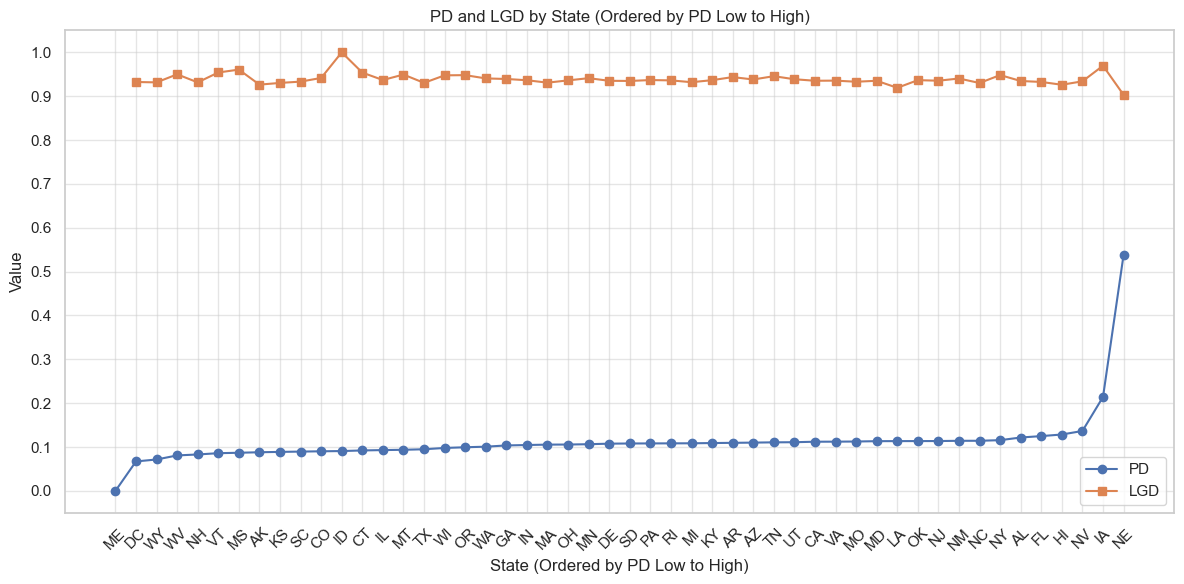

In [ ]:
# Calculate PD and LGD by addr_state
pd_by_state = loan_df.groupby('addr_state')['is_default'].mean()
default_loans_state = loan_df[loan_df['is_default'] == 1]
avg_lgd_by_state = default_loans_state.groupby('addr_state')['loss_given_default'].mean()

# Order by PD ascending
ordered_pd_state = pd_by_state.sort_values()
avg_lgd_reindexed = avg_lgd_by_state.reindex(ordered_pd_state.index)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(ordered_pd_state.index, ordered_pd_state.values, marker='o', label='PD', linestyle='-')
plt.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

plt.xlabel('State (Ordered by PD Low to High)')
plt.ylabel('Value')
plt.title('PD and LGD by State (Ordered by PD Low to High)')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Check the number of observations in ME, IA, NE
states_of_interest = ['ME', 'IA', 'NE', 'ID', 'DC']
for state in states_of_interest:
    count = loan_df[loan_df['addr_state'] == state].shape[0]
    print(f"Number of observations in {state}: {count}")

Number of observations in ME: 4
Number of observations in IA: 14
Number of observations in NE: 13
Number of observations in ID: 11
Number of observations in DC: 1398


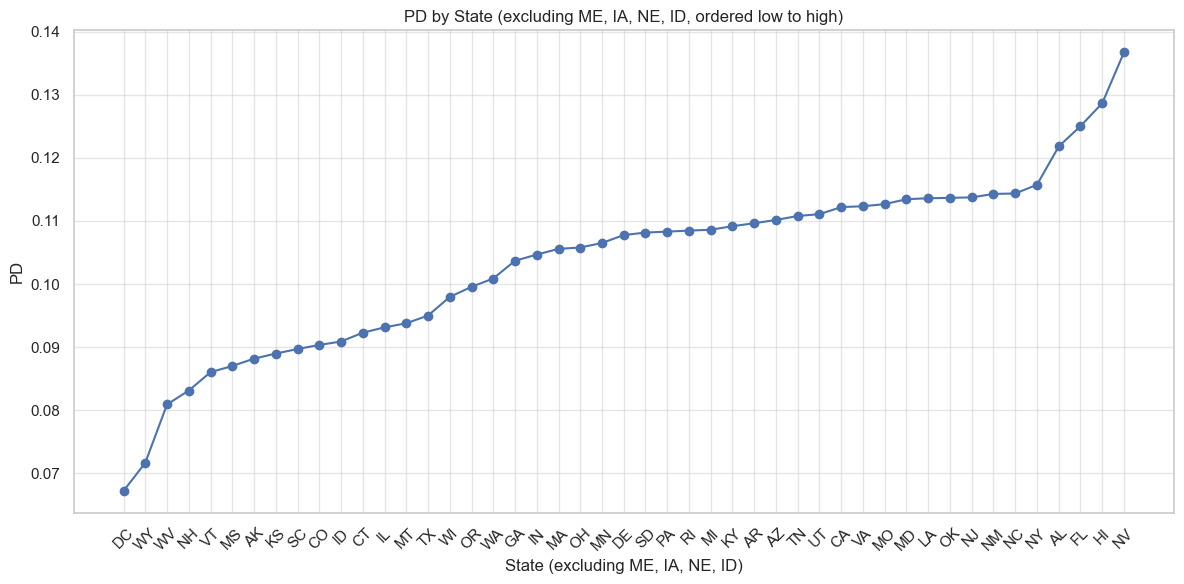

In [ ]:
# Filter out the states of interest
states_to_exclude = ['ME', 'IA', 'NE']
filtered_df = loan_df[~loan_df['addr_state'].isin(states_to_exclude)]

# Now, plot PD or LGD by state using the filtered data, e.g., for PD:
# Calculate PD by state
pd_by_state = filtered_df.groupby('addr_state')['is_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_state.sort_values()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(ordered_pd.index, ordered_pd.values, marker='o', linestyle='-')
plt.xlabel('State (excluding ME, IA, NE, ID)')
plt.ylabel('PD')
plt.title('PD by State (excluding ME, IA, NE, ID, ordered low to high)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

- **Insights:**

  1. The PD for borrowers residing in Maine, Iowa, and Nebraska varies compared to other states. However, the number of observations from these states is very low, so the estimates may not accurately represent the overall population in these states.
  
  2. Similarly, for LGD with borrowers residing in Idaho, the sample size is too small to be considered representative of the state's population characteristics.

  3. To mitigate high cardinality, states can be grouped based on their PD levels:

      - States with PD under 9%:
        ME, DC, WY, WV, NH, VT, MS, AK, KS, SC

      - States with PD between 9% and 10%:
        CO, ID, CT, IL, MT, TX, WI, OR

      - States with PD between 10% and 11%:
        WA, GA, IN, MA, OH, MN, DE, SD, PA, RI, MI, KY, AR

      - States with PD between 11% and 12%:
        AZ, TN, UT, CA, VA, MO, MD, LA, OK, NJ, NM, NC, NY

      - States with PD above 12%:
        AL, FL, HI, NV, IA, NE

---

#### 3.6.2 Loan Characteristics  <a class="anchor" id="3f2"></a>

- `purpose`

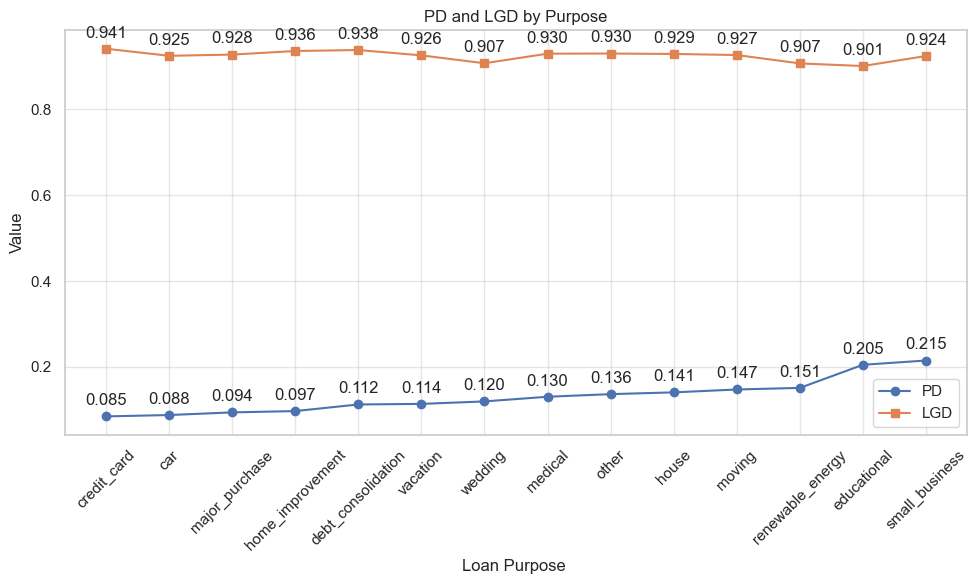

In [230]:
# Calculate PD and LGD by purpose
pd_by_purpose = loan_df.groupby('purpose')['is_default'].mean()
default_loans = loan_df[loan_df['is_default'] == 1]
avg_lgd_by_purpose = default_loans.groupby('purpose')['loss_given_default'].mean()

# Order by PD (low to high)
ordered_pd = pd_by_purpose.sort_values()
avg_lgd_reindexed = avg_lgd_by_purpose.reindex(ordered_pd.index)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
plt.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add labels with 3 decimal places
for x, y in zip(ordered_pd.index, ordered_pd.values):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_by_purpose.reindex(ordered_pd.index).values):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Loan Purpose ')
plt.ylabel('Value')
plt.title('PD and LGD by Purpose')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

**Insights:**

1. PD varies significantly across different loan types. Credit card and car/auto loans have the lowest PD, under 9%, while education and small business loans have the highest PD, exceeding 20%. The differences across groups are quite substantial.

2. The variation in PD across loan types highlights distinct risk characteristics, emphasizing the need to develop separate PD models for more accurate predictions.

3. LGD also differs by loan type, with education, wedding, and renewable energy loans exhibiting the lowest LGD around 90%, while credit card loans have the highest LGD at approximately 94%.

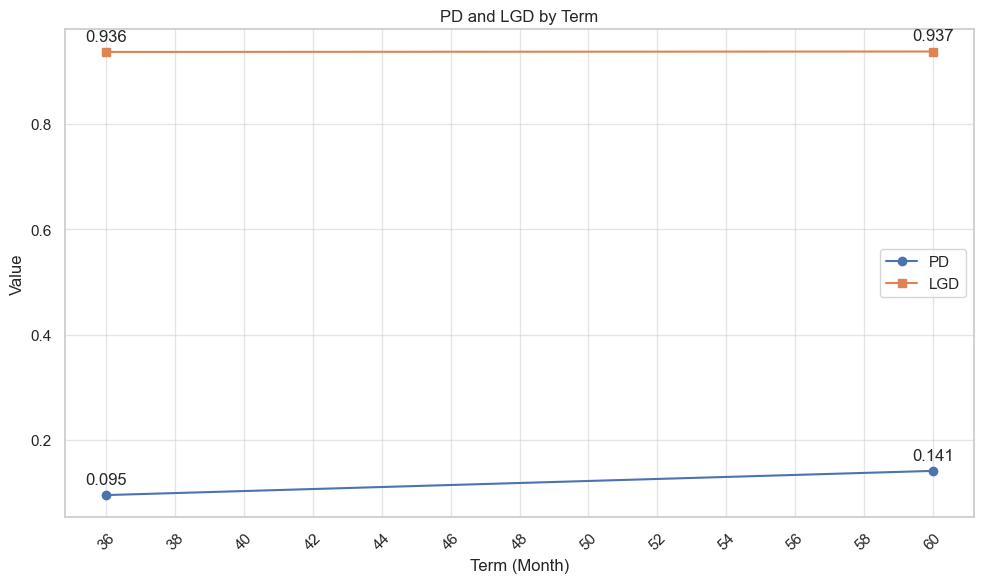

In [234]:
# Calculate PD and LGD by term
pd_by_term = loan_df.groupby('term')['is_default'].mean()
default_loans = loan_df[loan_df['is_default'] == 1]
avg_lgd_by_term = default_loans.groupby('term')['loss_given_default'].mean()

# Order by PD (low to high)
ordered_pd = pd_by_term.sort_values()
avg_lgd_reindexed = avg_lgd_by_term.reindex(ordered_pd.index)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
plt.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add labels with 3 decimal places
for x, y in zip(ordered_pd.index, ordered_pd.values):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_by_term.reindex(ordered_pd.index).values):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Term (Month)')
plt.ylabel('Value')
plt.title('PD and LGD by Term')
plt.legend()
plt.xticks(np.arange(36, 62, 2), rotation=45)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

**Insights:**

1. There are only two types of loan term structures in the dataset.

2. Loans with a 5-year term exhibit a notably higher PD.

- `loan_amnt`

In [ ]:
# Define the function to categorize loan sizes
def categorize_loan_size(amount):
    if amount < 10000:
        return 'Small Loan (<$10K)'
    elif amount <= 20000:
        return 'Medium Loan ($10K-$20K)'
    elif amount <= 30000:
        return 'Large Loan ($20K-$30K)' 
    else:
        return 'Very Large Loan (>$30K)'

# Apply the function and create a new df for plotting
plot_df = loan_df.copy()
plot_df['loan_size_category'] = plot_df['loan_amnt'].apply(categorize_loan_size)

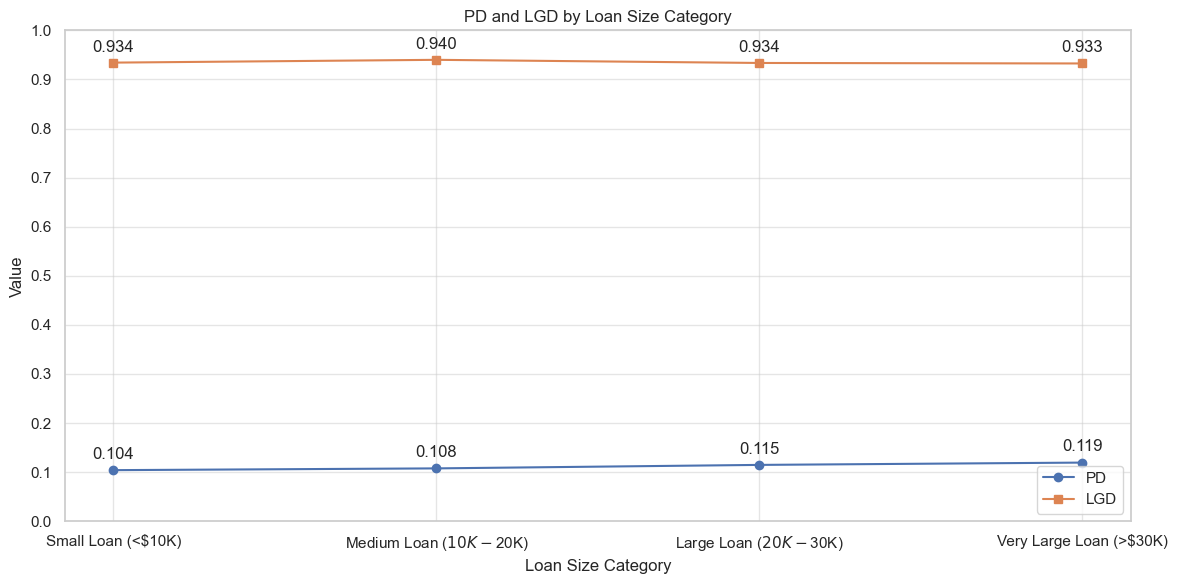

In [ ]:
# Calculate PD and LGD by loan_size_category
pd_by_size = plot_df.groupby('loan_size_category')['is_default'].mean()
default_loans = plot_df[plot_df['is_default'] == 1]
avg_lgd_by_size = default_loans.groupby('loan_size_category')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_size.sort_values()
avg_lgd_reindexed = avg_lgd_by_size.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add annotations next to PD points
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

# Add annotations next to LGD points
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Loan Size Category')
plt.ylabel('Value')
plt.title('PD and LGD by Loan Size Category')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

**Insights:**

1. Risk increases with loan size: The Probability of Default (PD) rises when moving from the 'Small Loan' category (approximately 10.4%) to the 'Large Loan' category (approximately 11.9%).


- `initial_list_status`

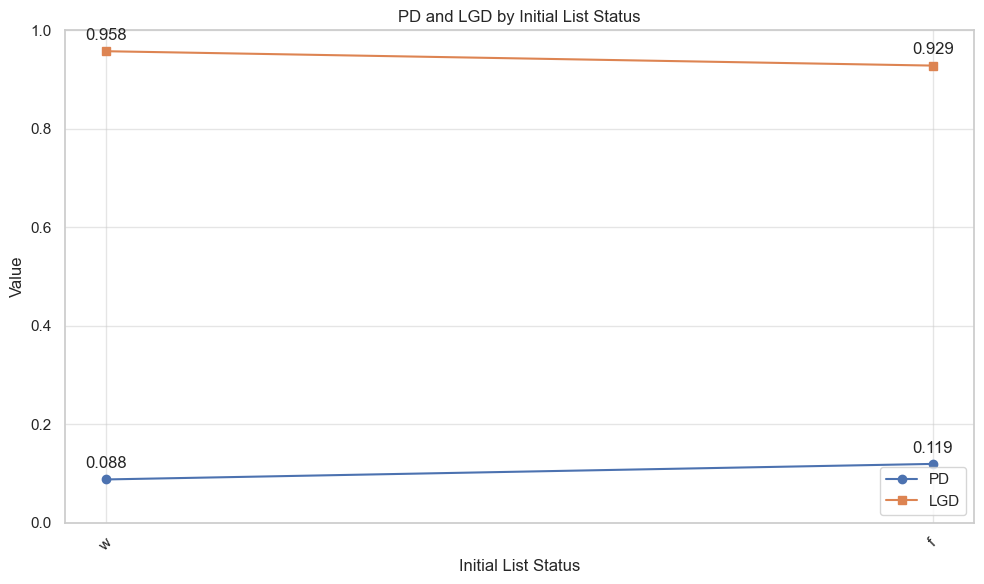

In [ ]:
# Calculate PD and LGD by initial_list_status
pd_by_status = loan_df.groupby('initial_list_status')['is_default'].mean()
default_loans_status = loan_df[loan_df['is_default'] == 1]
avg_lgd_by_status = default_loans_status.groupby('initial_list_status')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd_status = pd_by_status.sort_values()
avg_lgd_reindexed = avg_lgd_by_status.reindex(ordered_pd_status.index)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ordered_pd_status.index, ordered_pd_status.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add data labels with 3 decimal places
for x, y in zip(ordered_pd_status.index, ordered_pd_status.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

# Final touches
ax.set_xlabel('Initial List Status')
ax.set_ylabel('Value')
ax.set_title('PD and LGD by Initial List Status')
ax.legend()
ax.set_ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

- **Insights:**

1. `initial_list_status` indicates how the loan was financed. 'F' (Fully Funded) loans were backed by many individual retail investors on the open marketplace. 'W' (Whole Loan) status means the loan was bought in bulk by a single large institutional investor. Fully funded loans have higher PDs but lower LGD.

---


#### 3.6.3 Performance Metrics  <a class="anchor" id="3f3"></a>

- `delinq_2yrs`

In [ ]:
# Define the function to categorize delinquency count
def categorize_delinquency(count):

    if count == 0:
        return 'No Delinquency (0)'
    elif count <= 2:
        return 'Low Delinquency (1-2)'
    else:  # count >= 3
        return 'High Delinquency (3+)'

# Apply the function to create the new delinquency category column
plot_df['delinq_category'] = plot_df['delinq_2yrs'].apply(categorize_delinquency)

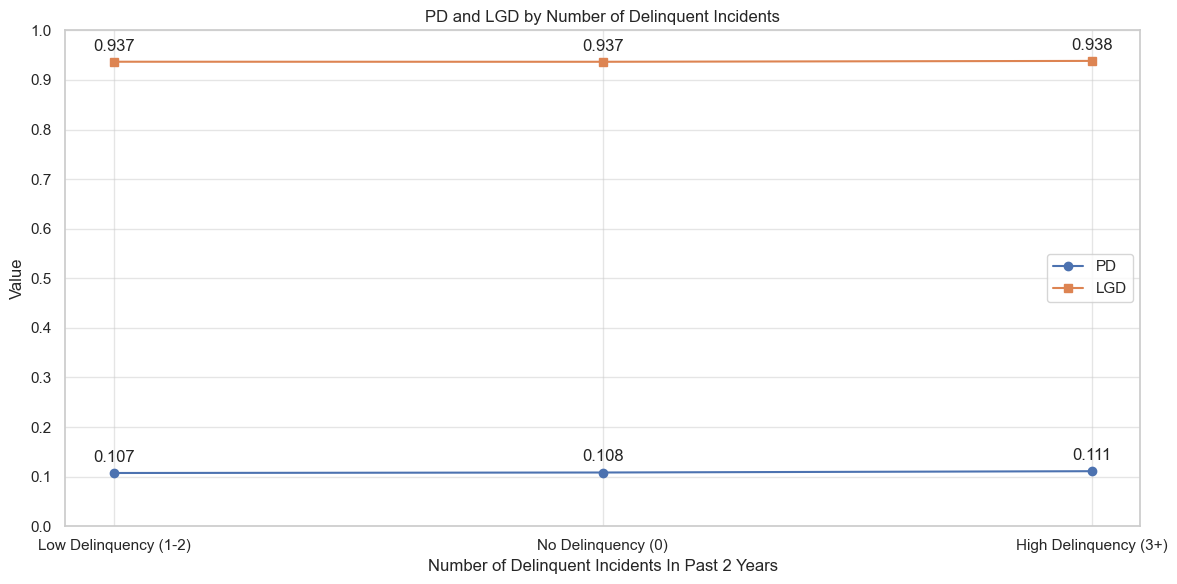

In [ ]:
# Calculate PD and LGD by delinq_category
pd_by_delinq_category = plot_df.groupby('delinq_category')['is_default'].mean()
default_loans = plot_df[plot_df['is_default'] == 1]
avg_lgd_by_delinq_category = default_loans.groupby('delinq_category')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_delinq_category.sort_values()
avg_lgd_reindexed = avg_lgd_by_delinq_category.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add number labels with :.3f
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Number of Delinquent Incidents In Past 2 Years')
plt.ylabel('Value')
plt.title('PD and LGD by Number of Delinquent Incidents')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

- Insights:

    There are no variations in PD and LGD across groups, so I will exclude these variables from our predictors in the subsequent stages.
    


- `mths_since_delinq_category`

In [ ]:
# Define the function to categorize months since last delinquency
def categorize_delinq_months(months):

    # 1. Handle NaN (Missing/No Delinquency Ever)
    if pd.isna(months):
        return 'Missing Values'

    # 2. Categorization logic for valid numeric months
    elif months <= 15:
        return 'Recent (0-15 Mths)'
    elif months <= 30:
        return 'Moderate (16-30 Mths)'
    elif months <= 45:
        return 'Old (31-45 Mths)'
    else:  # months > 45
        return 'Very Old (>45 Mths)'

# Apply the function to create the new delinquency months category column
plot_df['mths_since_delinq_category'] = plot_df['mths_since_last_delinq'].apply(categorize_delinq_months)

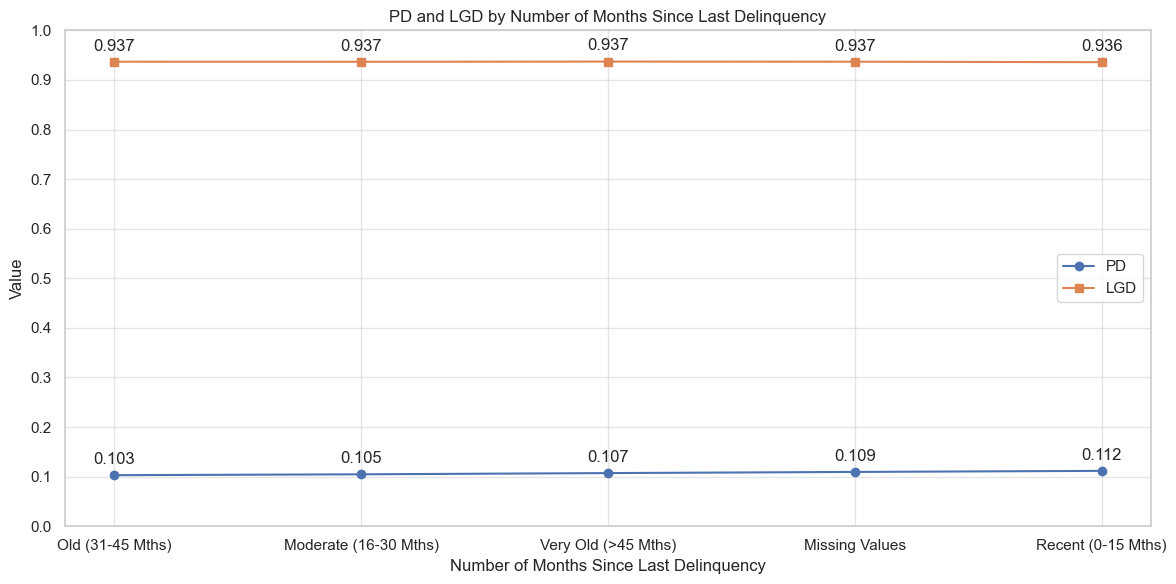

In [ ]:
# Calculate PD and LGD by mths_since_delinq_category
pd_by_mths_since_delinq_category = plot_df.groupby('mths_since_delinq_category')['is_default'].mean()
default_loans = plot_df[plot_df['is_default'] == 1]
avg_lgd_by_mths_since_delinq_category = default_loans.groupby('mths_since_delinq_category')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_mths_since_delinq_category.sort_values()
avg_lgd_reindexed = avg_lgd_by_mths_since_delinq_category.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add number labels with :.3f
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Number of Months Since Last Delinquency')
plt.ylabel('Value')
plt.title('PD and LGD by Number of Months Since Last Delinquency')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

**Insights:**

1. This column contains over 50% missing values.
2. There is no noticeable variation in both PD and LGD among different segments, indicating that this column can be excluded from the feature space.
    




- `inq_last_6mths`

In [ ]:
# Define the function to categorize credit inquiry count
def categorize_inquiries(count):

    if count == 0:
        return 'No Inquiries (0)'
    elif count <= 2:
        return 'Low Inquiries (1-2)'
    else:  # count >= 3
        return 'High Inquiries (3+)'

# Apply the function to create the new inquiries category column
plot_df['inquiries_category'] = plot_df['inq_last_6mths'].apply(categorize_inquiries)

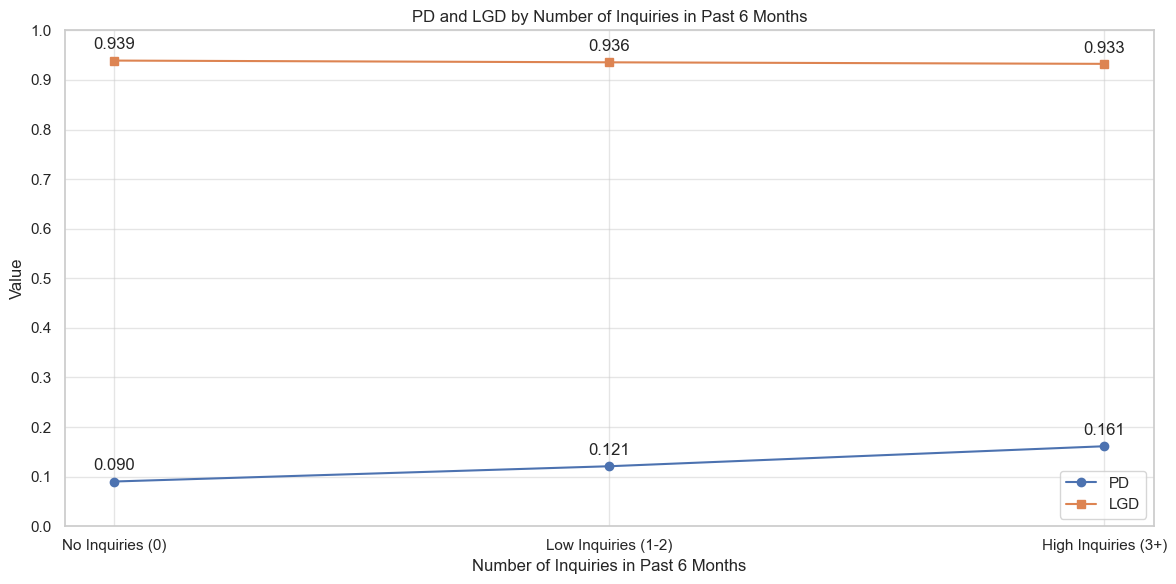

In [ ]:
# Calculate PD and LGD by inquiries_category
pd_by_inquiries_category = plot_df.groupby('inquiries_category')['is_default'].mean()
default_loans = plot_df[plot_df['is_default'] == 1]
avg_lgd_by_inquiries_category = default_loans.groupby('inquiries_category')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_inquiries_category.sort_values()
avg_lgd_reindexed = avg_lgd_by_inquiries_category.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add number labels with :.3f
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Number of Inquiries in Past 6 Months')
plt.ylabel('Value')
plt.title('PD and LGD by Number of Inquiries in Past 6 Months')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

**Insights:**

1. There is a positive correlation between the number of inquiries and PD. A higher number of inquiries (3 or more) may indicate a greater likelihood of higher PD compared to those with fewer inquiries.

- `total_acc`

In [ ]:
# Define the function to categorize total accounts
def categorize_total_acc(count):

    if count == 0:
        return 'None (0)'
    elif count <= 10:
        return 'Low (1-10)'
    elif count <= 20:
        return 'Moderate (11-20)'
    elif count <= 30:
        return 'High (21-30)'
    elif count <= 40:
        return 'Very High (31-40)'
    else:  # count > 40
        return 'Extreme (>40)'

# Apply the function to create the new total accounts category column
plot_df['total_acc_category'] = plot_df['total_acc'].apply(categorize_total_acc)

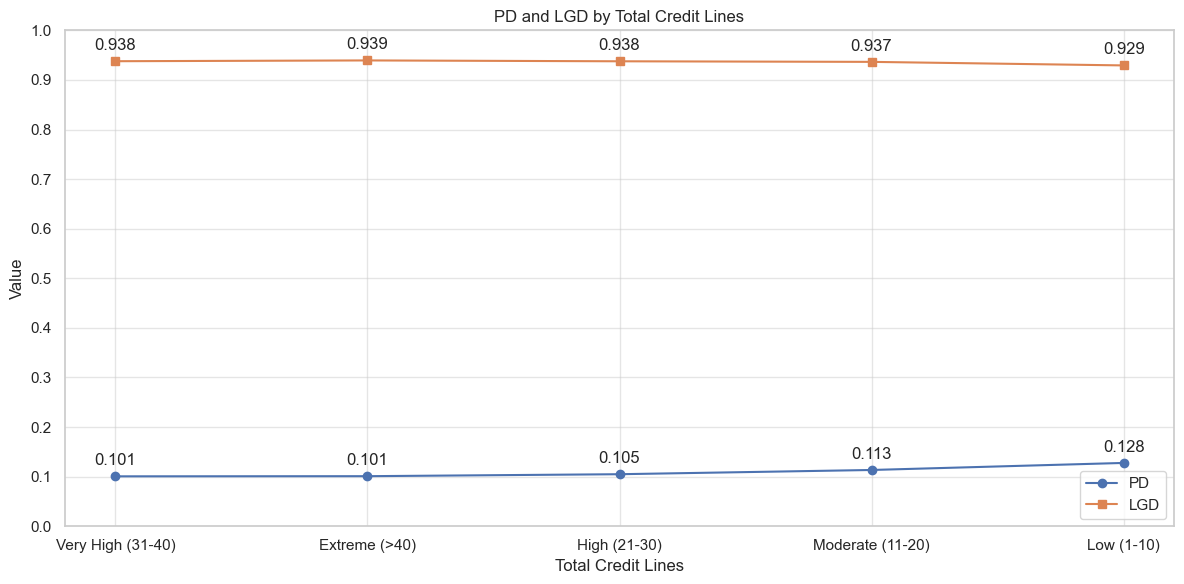

In [ ]:
# Calculate PD and LGD by total_acc_category
pd_by_total_acc_category = plot_df.groupby('total_acc_category')['is_default'].mean()
default_loans = plot_df[plot_df['is_default'] == 1]
avg_lgd_by_total_acc_category = default_loans.groupby('total_acc_category')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_total_acc_category.sort_values()
avg_lgd_reindexed = avg_lgd_by_total_acc_category.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add number labels with :.3f
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Total Credit Lines')
plt.ylabel('Value')
plt.title('PD and LGD by Total Credit Lines')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

**Insights:**

1. `total_acc` represents the total number of credit lines currently in the borrower's credit file. It appears that groups with total accounts over 21 share similar PD, while those with under 20 exhibit relatively higher PD.

2. Groups with `total_acc` over 21 can be aggregated together due to their similar risk characteristics.



- `pub_rec`

In [236]:
# Define the function to categorize pub_rec
def categorize_pub_rec(count):
    if count == 0:
        return 'None (0)'
    elif count <= 2:
        return 'Low (1-2)'
    else:  # count >= 3
        return 'High (3 or more)'

# Apply the function to create the new pub_rec category column
plot_df['pub_rec_category'] = plot_df['pub_rec'].apply(categorize_pub_rec)

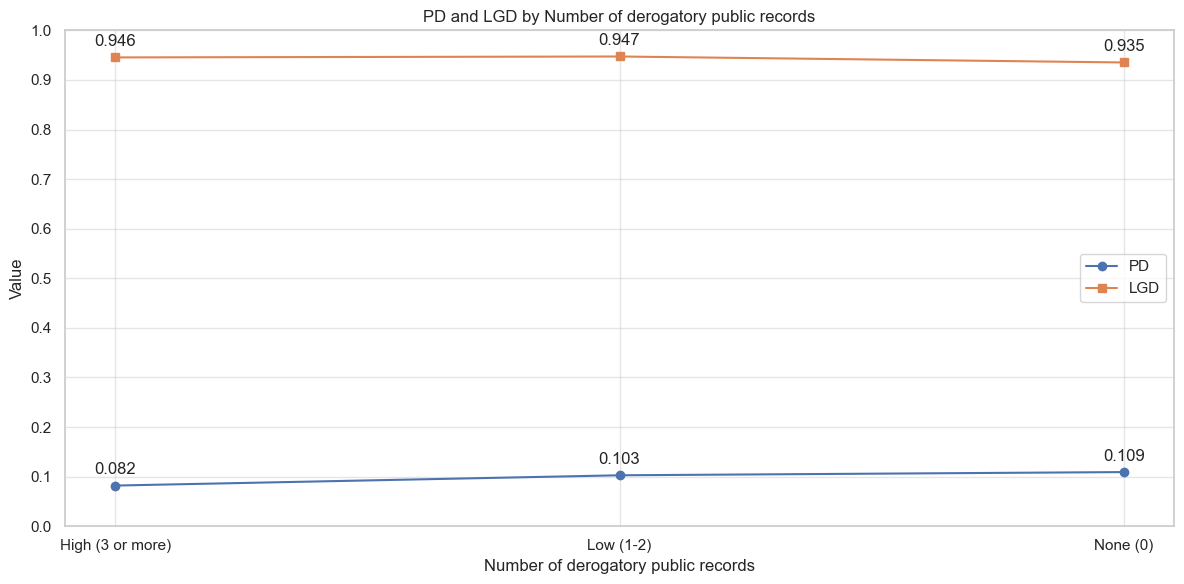

In [238]:
# Calculate PD and LGD by pub_rec category
pd_by_pub_rec = plot_df.groupby('pub_rec_category')['is_default'].mean()
default_loans_pub_rec = plot_df[plot_df['is_default'] == 1]
avg_lgd_by_pub_rec = default_loans_pub_rec.groupby('pub_rec_category')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd_pub_rec = pd_by_pub_rec.sort_values()
avg_lgd_reindexed_pub_rec = avg_lgd_by_pub_rec.reindex(ordered_pd_pub_rec.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd_pub_rec.index, ordered_pd_pub_rec.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed_pub_rec.index, avg_lgd_reindexed_pub_rec.values, marker='s', label='LGD', linestyle='-')

# Add number labels with :.3f
for x, y in zip(ordered_pd_pub_rec.index, ordered_pd_pub_rec.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed_pub_rec.index, avg_lgd_reindexed_pub_rec.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Number of derogatory public records')
plt.ylabel('Value')
plt.title('PD and LGD by Number of derogatory public records')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Check value counts
plot_df['pub_rec'].value_counts().sort_values(ascending=False)[:8]

pub_rec
0.0000    388607
1.0000     48721
2.0000      5167
3.0000      1467
4.0000       472
5.0000       254
6.0000       125
7.0000        59
8.0000        25
Name: count, dtype: int64

**Insights:**

1. Since most of the data is concentrated in the 0 bucket, the PD aligns with the overall PD within the dataset. The low varaince renders this feature relatively uninformative in predicting PD.


---

#### 3.6.4 Derived Features  <a class="anchor" id="3f4"></a>

- `dti` - debt to income ratio

In [ ]:
# Define the function to categorize DTI
def categorize_dti(amount):

    
    if amount < 10:
        return 'Very Low (0-10)'
    elif amount < 20:
        return 'Low (10-20)'
    elif amount < 35:
        return 'Moderate (20-35)'
    elif amount < 50:
        return 'High (35-50)'
    else:  # amount >= 50 (up to 1000, or effectively infinity)
        return 'Very High (>50)'

# Apply the function to create the new DTI category column
plot_df['dti_category'] = plot_df['dti'].apply(categorize_dti)

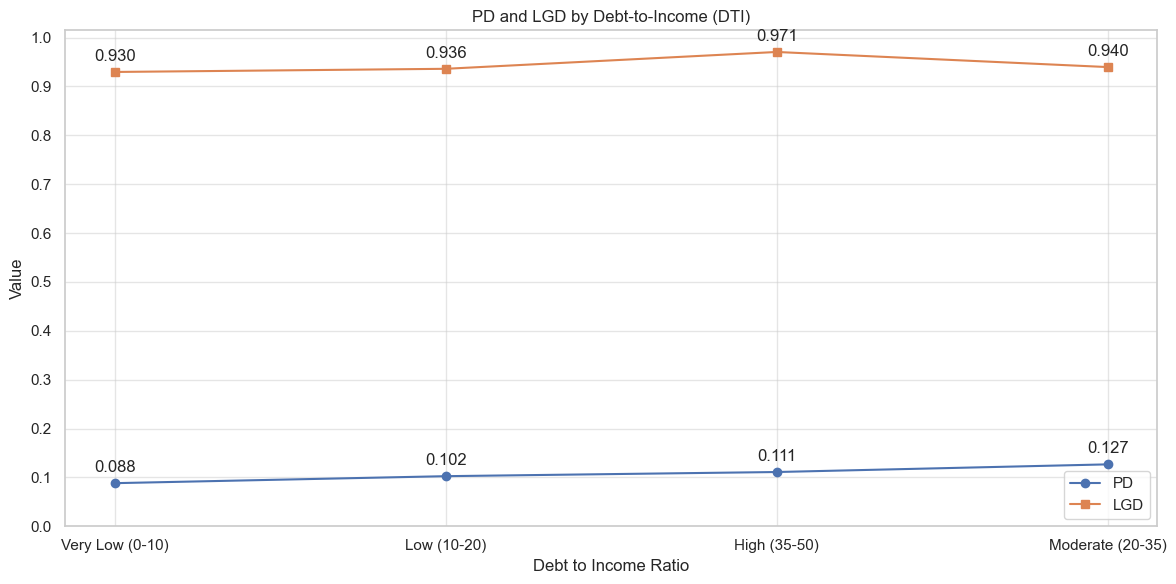

In [176]:
# Calculate PD and LGD by dti category
pd_by_dti = plot_df.groupby('dti_category')['is_default'].mean()
default_loans = plot_df[plot_df['is_default'] == 1]
avg_lgd_by_dti = default_loans.groupby('dti_category')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_dti.sort_values()
avg_lgd_reindexed = avg_lgd_by_dti.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add number labels with :.3f
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Debt to Income Ratio')
plt.ylabel('Value')
plt.title('PD and LGD by Debt-to-Income (DTI)')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

**Insights:**

1. `dti` represents the ratio of a borrower’s total monthly debt payments to their self-reported monthly income. A lower DTI indicates that the borrower has more income available to cover debt obligations. 

2. Overall, there appears to be a positive correlation between DTI and probability of default (PD). However, it is worth noting that the Moderate DTI group exhibits a higher PD than the High DTI group.



- `revol_util`

In [195]:
# Define the function to categorize utilization rate
def categorize_utilization(rate):
    
    # Categorization logic using the specified ranges
    if rate <= 30:
        # Note: 0-30 includes 30 due to the <= operator
        return 'Low Utilization (0-30%)'
    elif rate <= 60:
        return 'Moderate Utilization (30-60%)'
    elif rate <= 90:
        return 'High Utilization (60-90%)'
    else:  # rate > 90
        return 'Very High Utilization (>90%)'

# Apply the function to create the new utilization category column
plot_df['revol_util'] = plot_df['revol_util'].apply(categorize_utilization)

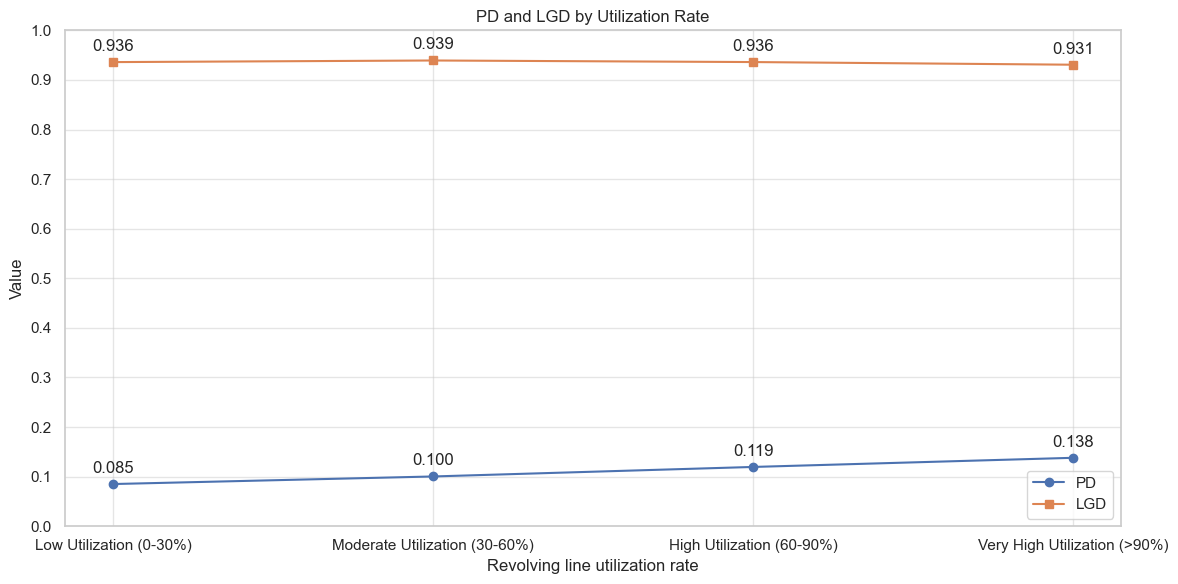

In [205]:
# Calculate PD and LGD by revol_util category
pd_by_revol_util = plot_df.groupby('revol_util')['is_default'].mean()
default_loans = plot_df[plot_df['is_default'] == 1]
avg_lgd_by_revol_util = default_loans.groupby('revol_util')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_revol_util.sort_values()
avg_lgd_reindexed = avg_lgd_by_revol_util.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add number labels with :.3f
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Revolving Line Utilization Rate')
plt.ylabel('Value')
plt.title('PD and LGD by Utilization Rate')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

**Insights:**

1. There is a positive correlation with the utilization rate; as the amount of revolving credit utilization increases, PD also rises. This suggests that high credit line utilization may be a warning signal of higher PD.

- `out_prncp` -> outstanding principle ratio

This variable represents remaining outstanding principal for total amount funded. Since the funded amounts varies across loans, it is more effective to normalize this value using $$\text{Outstanding Principal Ratio} = \frac{\text{Outstanding Principal} (\text{out\_prncp})}{\text{Funded Amount} (\text{funded\_amnt})}$$

In [201]:
# Creata a new feature outstanding principle ratio
plot_df['out_prncp_ratio'] = plot_df['out_prncp'] / plot_df['funded_amnt']

plot_df['out_prncp_ratio'].describe()

count   444949.0000
mean         0.2749
std          0.3099
min          0.0000
25%          0.0000
50%          0.0332
75%          0.5838
max          0.9505
Name: out_prncp_ratio, dtype: float64

In [ ]:
# Define the function to categorize the Outstanding Principal Ratio
def categorize_principal_ratio(ratio):

    if ratio <= 0.33:
        return 'High Repayment (<33% Principle Remaining)'
    elif ratio <= 0.66:
        return 'Moderate Repayment (33%-66% Principle Remaining)'
    else:  # ratio > 0.66
        return 'Low Repayment (>66% Principle Remaining)'

# Apply the function to create the new category column
plot_df['out_prncp_ratio_category'] = plot_df['out_prncp_ratio'].apply(categorize_principal_ratio)

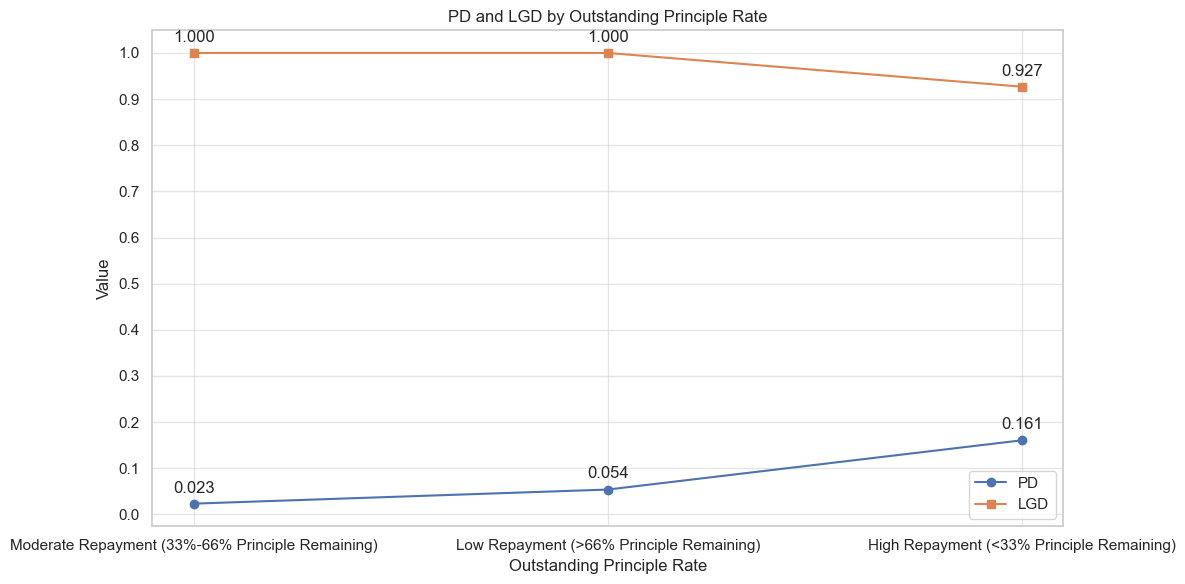

In [215]:
# Calculate PD and LGD by out_prncp_ratio_category 
pd_by_out_prncp_ratio_category = plot_df.groupby('out_prncp_ratio_category')['is_default'].mean()
default_loans = plot_df[plot_df['is_default'] == 1]
avg_lgd_by_out_prncp_ratio_category = default_loans.groupby('out_prncp_ratio_category')['loss_given_default'].mean()

# Order by PD from low to high
ordered_pd = pd_by_out_prncp_ratio_category.sort_values()
avg_lgd_reindexed = avg_lgd_by_out_prncp_ratio_category.reindex(ordered_pd.index)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ordered_pd.index, ordered_pd.values, marker='o', label='PD', linestyle='-')
ax.plot(avg_lgd_reindexed.index, avg_lgd_reindexed.values, marker='s', label='LGD', linestyle='-')

# Add number labels with :.3f
for x, y in zip(ordered_pd.index, ordered_pd.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
for x, y in zip(avg_lgd_reindexed.index, avg_lgd_reindexed.values):
    ax.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

plt.xlabel('Outstanding Principle Rate')
plt.ylabel('Value')
plt.title('PD and LGD by Outstanding Principle Rate')
plt.legend()
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

**Insights:**

1. Interestingly, individuals with high repayment rates and a lower percentage of remaining principal balance have a higher PD.

2. The variable `out_prncp` (Outstanding Principal) and its derived ratio are highly susceptible to data leakage in the PD model. A zero value in `out_prncp` often directly indicates the loan's current status (either fully paid or charged off), which is information that cannot be known when predicting a user's PD at the time of loan issuance. Therefore, these features must be excluded from the PD model to maintain predictive integrity.

3. The same leaky information includes: `total_rec_late_fee`, `total_rec_prncp`, `total_rec_int`, `total_pymnt`, and `last_pymnt_amnt`.


---

## 4. Summary <a class="anchor" id="4"></a>

| **Risk Characteristics**   | **Details**                                                                                                                    |
|----------------------------|-------------------------------------------------------------------------------------------------------------------------------|
| **PD**                     | 1. Long-term PD is at 10.8%.                                                                                                 |
|                            | 2. PD Point In Time (monthly PD) changes over time and is not static. We should retrain PD model regularly or calibrate Long-term PD models to be forward-looking. |
|                            | 3. While currently unavailable, incorporating macroeconomic factors might help the model capture the economic effect on PD.   |
| **LGD**                    | 1. Long-term LGD exhibits a bimodal distribution with peaks at 1.0 and around 0.85.                                         |
|                            | 2. The peak at 0.85 might suggest that defaulted loans are auctioned or insured for a fixed rate.                             |
|                            | 3. The distribution of LGD slightly changed year over year, with one peak relatively stable at 1 and another peak changing across years. |
|                            | 4. It is important to model LGD regularly and incorporate macroeconomic variables if possible to reflect LGD Point In Time.   |
| **EAD**                    | 1. EAD exhibits a right-skewed distribution with a peak around $3,000-5,000 and large tails above $35,000.                    |
|                            | 2. Compared to PD and LGD, EAD distribution is relatively stable across years, but the peak value around $3,000-5,000 has gradually increased over years, indicating increasing exposure to credit risk. |
|                            | 3. Due to the lack of data like credit withdrawn upon default for our revolving loans, I am unable to build a Credit Conversion Factor Model. The EAD will simply be Funded Credit - Total principal repaid. No modeling is needed. |






| **Borrower Characteristics** | **Details**                                                                                                                 |
|-----------------------------|---------------------------------------------------------------------------------------------------------------------------|
| **Grade**  **Sub-Grade**                 | 1. Grade is similar to the FICO score, which reflects the borrower's credibility.                                        |
|                             | 2. There is a negative relationship with PD; higher grades (A) exhibit the lowest PD, while the lowest grade (G) exhibits significantly higher PD. |
| **Home Ownership**          | 1. Individuals with homes (mortgage or owned) exhibit slightly lower PD.                                                |
| **Address State**           | 1. PD varies slightly across different states in the U.S., with the lowest PD around 8% and Nevada showing the highest PD over 13.5%. |
| **Annual Income**           | 1. There is a negative correlation with PD; borrowers with lower incomes exhibit higher PD.                              |
| **Employment Length**       | 1. The relationship does not appear strictly linear; individuals with over 10 years of working experience have the lowest PD, while those with no work experience or less than 1 year exhibit the highest PD. | 

| **Loan Characteristics**    | **Details**                                                                                                                  |
|-----------------------------|------------------------------------------------------------------------------------------------------------------------------|
| **Loan Amount**             | 1. Loan amount exhibits a positive correlation with PD; small loans (<$10K) have the lowest PD, while very large loans (>$30K) have the highest PD. |
| **Purpose**                 | 1. Risk characteristics vary across different loan products, with credit card and car loans exhibiting the lowest PD around 8.5%, while both educational and small business loans have PD over 20%. |
| **Initial List Status**     | 1. Fully funded loans exhibit higher PD than whole loans.                                                                   |

| **Performance Metrics**                            | **Details**                                                                                                                  |
|---------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------|
| **Number of Inquiries in 6 months**               | 1. PD increases as the number of inquiries increases; 0 inquiry history exhibits the lowest PD.                             |
| **Total Accounts**                                 | 1. Borrowers with the lowest number of credit lines exhibit the highest PD.                                                |
| **Initial List Status**                            | 1. Fully funded loans exhibit higher PD than whole loans.                                                                   |


| **Derived Features**        | **Details**                                                                                                                  |
|-----------------------------|------------------------------------------------------------------------------------------------------------------------------|
| **Debt to Income Ratio**    | 1. A low DTI ratio is linked to low PD, while the correlation between high DTI and PD remains unclear.                       |
| **Utilization Rate**        | 1. PD is positively correlated with utilization rate, as a high revolving utilization rate links to higher PD.               |

| **Preprocessing Insights**                                                           | **Details**                                                                                                                                                                               |
|--------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `funded_amnt`, `loan_amnt`, `installment`                                          | Strong correlation among the three variables.                                                                                                                                                 |
| `total_rec_prncp`, `total_pymnt`, `total_rec_int`                                 | Multicollinearity exists because: $\mathbf{\text{Total Payments}} = \mathbf{\text{Principal}} + \mathbf{\text{Interest}} + \mathbf{\text{Fees}}$. Strong correlation between `total_rec_prncp`, `total_pymnt`. |
| `total_acc` and `open_acc`                                                         | Strong correlation as they both represent the number of accounts owned by a borrower.                                                                                                      |
| `total_rev_hi_lim` and `revol_bal`                                                | Both variables can be dropped as they can be represented by `revol_util`.                                                                                                                |
| `total_rec_late_fee`, `total_rec_prncp`, `total_rec_int`, `total_pymnt`, `last_pymnt_amnt` | Leaky features; such information will not be available in real life when predicting a user's PD today.                                                                                   |
| `grade` and `sub_grade`                                                             | Since `sub_grade` is merely a more granular credit score of `grade`, one of these variables should be excluded when training the model.                                                  |
| `annual_inc` and `inq_last_6mths`                                                  | Presence of outliers in these features.                                                                                                                                                   |
| `home_ownership`                                                                    | The low values in "NONE" and "ANY" can be grouped into "OTHER".                                                                                                                          |
| `addr_state`                                                                        | States can be grouped based on shared risk characteristics.                                                                                                                                 |
| `delinq_2yrs`, `mths_since_delinq_category`                                        | Both features are not informative in PD and LGD and can be dropped. NaNs in `mths_since_delinq_category` should be removed.                                                             |
| `pub_rec`                                                                          | Low variance feature; can be dropped.                                                                                                                                                      |